# 🏦 Projeto Final — Detecção de Fraude em Transações Bancárias
 
**Dataset:** 284.807 transações de cartão de crédito (setembro de 2023)

---

## 🎯 Objetivo

Desenvolver um modelo preditivo capaz de identificar fraudes em transações bancárias em um cenário de **dados altamente desbalanceados** (apenas 0,172% das transações são fraudes).

A métrica prioritária, conforme solicitado, é a **minimização de falsos negativos**, que são fraudes não detectadas pelo sistema. As métricas de avaliação utilizadas serão **F1-Score, Recall, Precision e AUC-ROC**.

> **Por que não utilizar acurácia?**  
> Um modelo que classifique 100% das transações como legítimas atingiria 99,83% de acurácia e ainda assim deixaria passar todas as 492 fraudes do dataset. A acurácia é uma métrica inadequada quando as classes são severamente desproporcionais.

---

## 📋 Estrutura do Projeto
1. Importações e Configuração do Ambiente
2. Carregamento e Entendimento dos Dados
3. Análise Exploratória de Dados (EDA)
4. Pré-processamento
5. Tratamento do Desbalanceamento (SMOTETomek)
6. Modelagem Baseline — Regressão Logística, Random Forest, XGBoost
7. Comparação Baseline
8. Otimização de Hiperparâmetros — Três Modelos
9. Comparação Final — Modelos Otimizados
10. Validação Final — Modelo Vencedor
11. Conclusões e Recomendações ao Stakeholder

---
## 1. 📦 Importações e Configuração do Ambiente

### Por que fazemos isso?
Antes de qualquer análise, é necessário importar todas as bibliotecas utilizadas no projeto e definir configurações globais.

Cada grupo de bibliotecas tem uma função específica:
- **pandas / numpy:** Manipulação e operações matemáticas sobre os dados
- **matplotlib / seaborn:** Criação de gráficos e visualizações
- **scikit-learn:** Algoritmos de machine learning, métricas e utilitários de pré-processamento
- **imbalanced-learn:** Técnicas especializadas para dados desbalanceados
- **xgboost:** Algoritmo de gradient boosting

O `RANDOM_STATE = 42` garante **reprodutibilidade total**: qualquer execução deste notebook produzirá os mesmos resultados, o que é fundamental para auditoria e validação em ambiente bancário.

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import kagglehub
from kagglehub import KaggleDatasetAdapter

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.combine import SMOTETomek
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, recall_score, precision_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ Ambiente configurado com sucesso!')
print('   RANDOM_STATE=42 garante reprodutibilidade total dos resultados.')

✅ Ambiente configurado com sucesso!
   RANDOM_STATE=42 garante reprodutibilidade total dos resultados.


---
## 2. 📂 Carregamento e Entendimento dos Dados

### Por que fazemos isso?
Antes de construir qualquer modelo, é necessário compreender a estrutura do dataset — tipos de variáveis, presença de valores ausentes e distribuição dos dados. Esta etapa documenta formalmente as características do dado de entrada que o modelo espera em produção.

### Onde será aplicado?
Qualquer alteração futura no dataset — novas colunas, mudança de tipo ou surgimento de valores nulos — precisa ser identificada nesta etapa antes que dados inconsistentes contaminem o modelo em produção.

In [ ]:
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rafaelarrosa/fraudes-cartao-credito-tcc-cd",
  "Base_M43_Pratique_CREDIT_CARD_FRAUD.csv"
)

print('=' * 65)
print('📊 VISÃO GERAL DO DATASET')
print('=' * 65)
print(f'Dimensões      : {df.shape[0]:,} linhas × {df.shape[1]} colunas')
print(f'Período coberto : 2 dias de setembro de 2023')
print(f'Volume diário   : ~{df.shape[0]//2:,} transações/dia')
print()
print('Tipos de dados:')
print(df.dtypes.value_counts())
print()
nulls = df.isnull().sum()
print('Valores nulos:')
print('✅ Nenhum valor nulo encontrado.' if nulls.sum() == 0 else nulls[nulls > 0])

📊 VISÃO GERAL DO DATASET
Dimensões      : 284,807 linhas × 31 colunas
Período coberto : 2 dias de setembro de 2023
Volume diário   : ~142,403 transações/dia

Tipos de dados:
float64    30
int64       1
Name: count, dtype: int64

Valores nulos:
✅ Nenhum valor nulo encontrado.


In [3]:
# Distribuição da variável alvo
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100

print('=' * 65)
print('🎯 DISTRIBUIÇÃO DA VARIÁVEL ALVO (Class)')
print('=' * 65)
print(f'Transações Legítimas   (0): {class_counts[0]:>7,}  ({class_pct[0]:.3f}%)')
print(f'Transações Fraudulentas(1): {class_counts[1]:>7,}  ({class_pct[1]:.3f}%)')
print(f'Razão de desbalanceamento : 1 fraude para cada {int(class_counts[0]/class_counts[1])} transações legítimas')
print()

valor_medio_fraude = df[df['Class']==1]['Amount'].mean()
prejuizo_2dias     = class_counts[1] * valor_medio_fraude
print('─' * 65)
print('💰 ESTIMATIVA DE IMPACTO FINANCEIRO')
print('─' * 65)
print(f'Valor médio por fraude  : R$ {valor_medio_fraude:.2f}')
print(f'Prejuízo potencial (2d) : R$ {prejuizo_2dias:,.2f}')
print(f'Projeção mensal         : R$ {prejuizo_2dias * 15:,.2f}')

🎯 DISTRIBUIÇÃO DA VARIÁVEL ALVO (Class)
Transações Legítimas   (0): 284,315  (99.827%)
Transações Fraudulentas(1):     492  (0.173%)
Razão de desbalanceamento : 1 fraude para cada 577 transações legítimas

─────────────────────────────────────────────────────────────────
💰 ESTIMATIVA DE IMPACTO FINANCEIRO
─────────────────────────────────────────────────────────────────
Valor médio por fraude  : R$ 122.21
Prejuízo potencial (2d) : R$ 60,127.97
Projeção mensal         : R$ 901,919.55


In [4]:
print('=' * 65)
print('📈 ESTATÍSTICAS — VARIÁVEIS ORIGINAIS (não transformadas por PCA)')
print('=' * 65)
stats = df[['Time', 'Amount', 'Class']].describe().round(2)
display(stats)

print()
print('Interpretação das estatísticas de Amount:')
print(f'   Mediana (50%): R$ {df["Amount"].median():.2f}  - valor "típico" de uma transação')
print(f'   Média        : R$ {df["Amount"].mean():.2f}  - puxada para cima pelos valores extremos')
print(f'   Máximo       : R$ {df["Amount"].max():,.2f}  - outlier extremo')
print(f'   75% das transações são abaixo de R$ {df["Amount"].quantile(0.75):.2f}')
print()
print('Interpretação de Time:')
print(f'   A coleta durou {df["Time"].max()/3600:.1f} horas (~2 dias)')
print(f'   Transações distribuídas ao longo de todo o período')

📈 ESTATÍSTICAS — VARIÁVEIS ORIGINAIS (não transformadas por PCA)


,Time,Amount,Class
count,284807.00,284807.00,284807.00
mean,94813.86,88.35,0.00
std,47488.15,250.12,0.04
min,0.00,0.00,0.00
25%,54201.50,5.60,0.00
50%,84692.00,22.00,0.00
75%,139320.50,77.16,0.00
max,172792.00,25691.16,1.00



Interpretação das estatísticas de Amount:
   Mediana (50%): R$ 22.00  - valor "típico" de uma transação
   Média        : R$ 88.35  - puxada para cima pelos valores extremos
   Máximo       : R$ 25,691.16  - outlier extremo
   75% das transações são abaixo de R$ 77.16

Interpretação de Time:
   A coleta durou 48.0 horas (~2 dias)
   Transações distribuídas ao longo de todo o período


### Conclusões do Entendimento dos Dados

| Característica | Observação | Implicação para a modelagem |
|---|---|---|
| Zero valores nulos | Dataset íntegro | Sem necessidade de imputação |
| V1–V28 são componentes PCA | Dados anonimizados pelo banco | Já normalizados; não exigem escalonamento |
| `Amount` assimétrico | Mediana R$22 vs máximo R$25.691 | Exige RobustScaler |
| 492 fraudes em 284.807 transações | Desbalanceamento severo (1:577) | Acurácia é métrica inadequada; exige SMOTETomek |
| Prejuízo potencial R$60k em 2 dias | Alto impacto financeiro | Justifica investimento em modelo robusto |

---
## 3. 🔍 Análise Exploratória de Dados (EDA)

### Por que fazemos isso?
A EDA permite identificar padrões, anomalias e relações entre variáveis que guiarão as decisões técnicas nas etapas seguintes, como escolha de escalonamento, técnica de balanceamento e algoritmos de modelagem.

### Onde será aplicado?
Os insights da EDA justificam diretamente cada decisão técnica documentada nas seções seguintes e fornecem ao stakeholder uma visão interpretável do comportamento das fraudes no dataset.

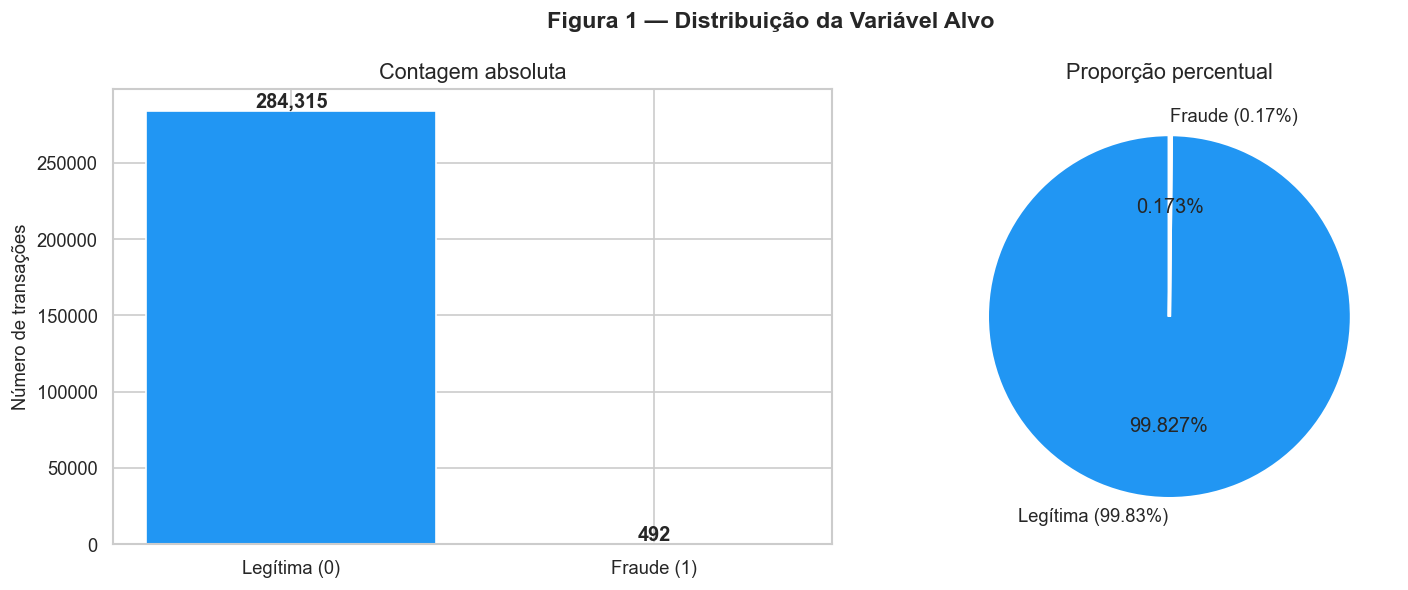

In [5]:
fraud      = df[df['Class'] == 1]
legitimate = df[df['Class'] == 0]

# ── Figura 1: Desbalanceamento ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figura 1 — Distribuição da Variável Alvo', fontsize=14, fontweight='bold')

colors = ['#2196F3', '#F44336']
axes[0].bar(['Legítima (0)', 'Fraude (1)'], class_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Contagem absoluta')
axes[0].set_ylabel('Número de transações')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(class_counts.values,
            labels=['Legítima (99.83%)', 'Fraude (0.17%)'],
            colors=colors, autopct='%1.3f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporção percentual')

plt.tight_layout()
plt.savefig('fig1_desbalanceamento.png', bbox_inches='tight')
plt.show()

**INTERPRETAÇÃO — Desbalanceamento das Classes**

O dataset apresenta desbalanceamento severo: 1 fraude para cada 577 transações legítimas. Isso cria um falso senso estatística:

- *Um modelo comum que classifica TUDO como legítimo teria 99,83% de acurácia e seria completamente ineficaz, pois não detectaria nenhuma das 492 fraudes.*

Isso explica por que nossa métrica principal é o Recall e o F1-Score, e não a acurácia. Precisamos de um modelo que aprenda a identificar padrões nas raras transações fraudulentas.

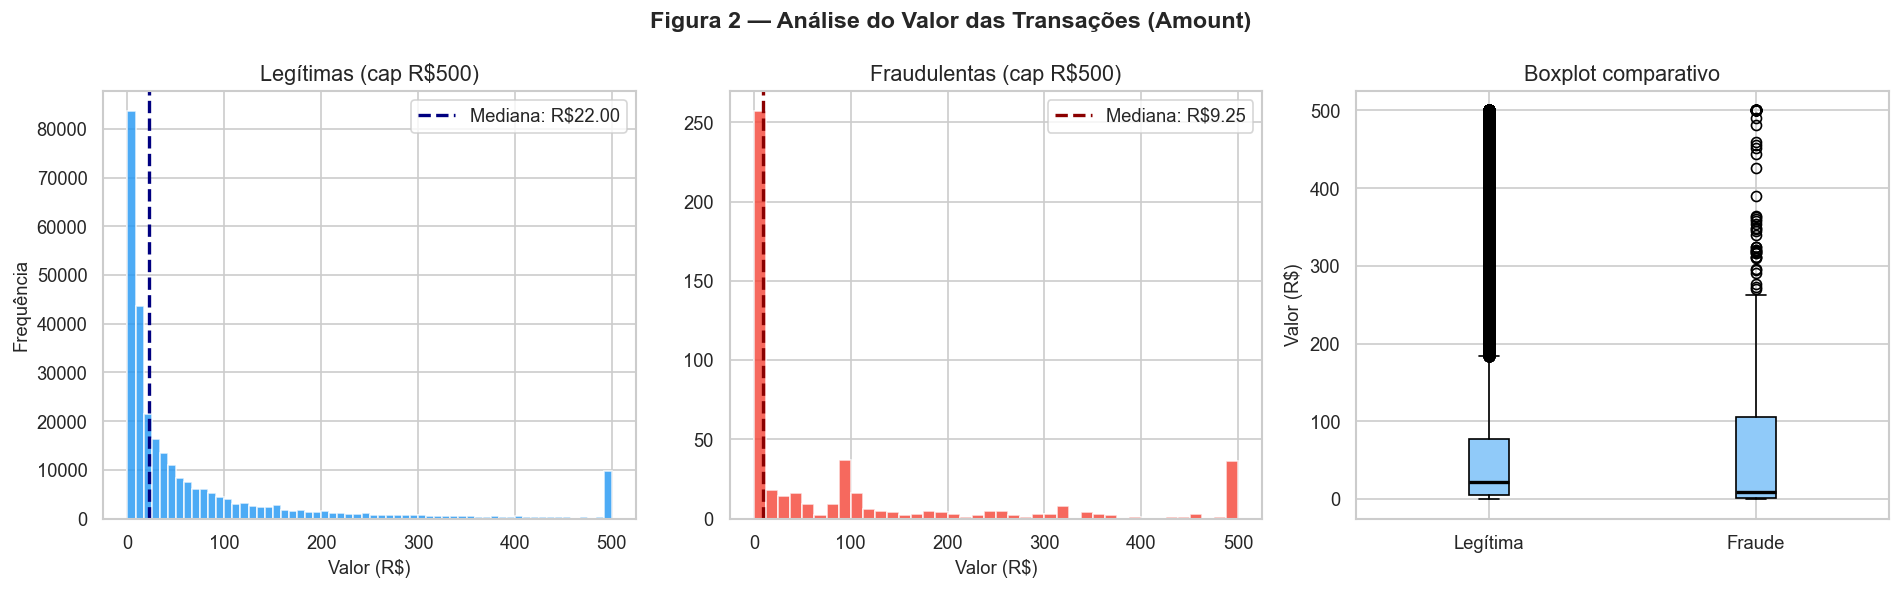

Dados sobre os aspectos das transações legitimas e fraudulentas
  Mediana legítimas : R$ 22.00
  Mediana fraudes   : R$ 9.25
  Média fraudes     : R$ 122.21
  Máximo fraudes    : R$ 2125.87


In [6]:
# ── Figura 2: Amount por classe ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figura 2 — Análise do Valor das Transações (Amount)', fontsize=14, fontweight='bold')

# Transações legítimas
axes[0].hist(legitimate['Amount'].clip(upper=500), bins=60, color='#2196F3', alpha=0.8, edgecolor='white')
axes[0].set_title('Legítimas (cap R$500)')
axes[0].set_xlabel('Valor (R$)')
axes[0].set_ylabel('Frequência')
axes[0].axvline(legitimate['Amount'].median(), color='navy', linestyle='--', linewidth=2,
                label=f'Mediana: R${legitimate["Amount"].median():.2f}')
axes[0].legend()

# Transações fraudulentas
axes[1].hist(fraud['Amount'].clip(upper=500), bins=40, color='#F44336', alpha=0.8, edgecolor='white')
axes[1].set_title('Fraudulentas (cap R$500)')
axes[1].set_xlabel('Valor (R$)')
axes[1].axvline(fraud['Amount'].median(), color='darkred', linestyle='--', linewidth=2,
                label=f'Mediana: R${fraud["Amount"].median():.2f}')
axes[1].legend()

axes[2].boxplot([legitimate['Amount'].clip(upper=500), fraud['Amount'].clip(upper=500)],
                labels=['Legítima', 'Fraude'], patch_artist=True,
                boxprops=dict(facecolor='#90CAF9'),
                medianprops=dict(color='black', linewidth=2))
axes[2].set_title('Boxplot comparativo')
axes[2].set_ylabel('Valor (R$)')

plt.tight_layout()
plt.savefig('fig2_amount.png', bbox_inches='tight')
plt.show()

print('Dados sobre os aspectos das transações legitimas e fraudulentas')
print(f'  Mediana legítimas : R$ {legitimate["Amount"].median():.2f}')
print(f'  Mediana fraudes   : R$ {fraud["Amount"].median():.2f}')
print(f'  Média fraudes     : R$ {fraud["Amount"].mean():.2f}')
print(f'  Máximo fraudes    : R$ {fraud["Amount"].max():.2f}')

**INTERPRETAÇÃO — Valor das Transações Fraudulentas**

**INSIGHT CRÍTICO**: As medianas são próximas, o que revela uma característica importante do comportamento dos fraudadores:
- Eles deliberadamente evitam valores que chamem atenção.

Isso significa que filtrar por valor alto NÃO é suficiente para detectar fraudes. O padrão está nos componentes PCA
(V1-V28), não no Amount em isolamento. Isso justifica o uso de machine learning em vez de regras simples baseadas em valor.


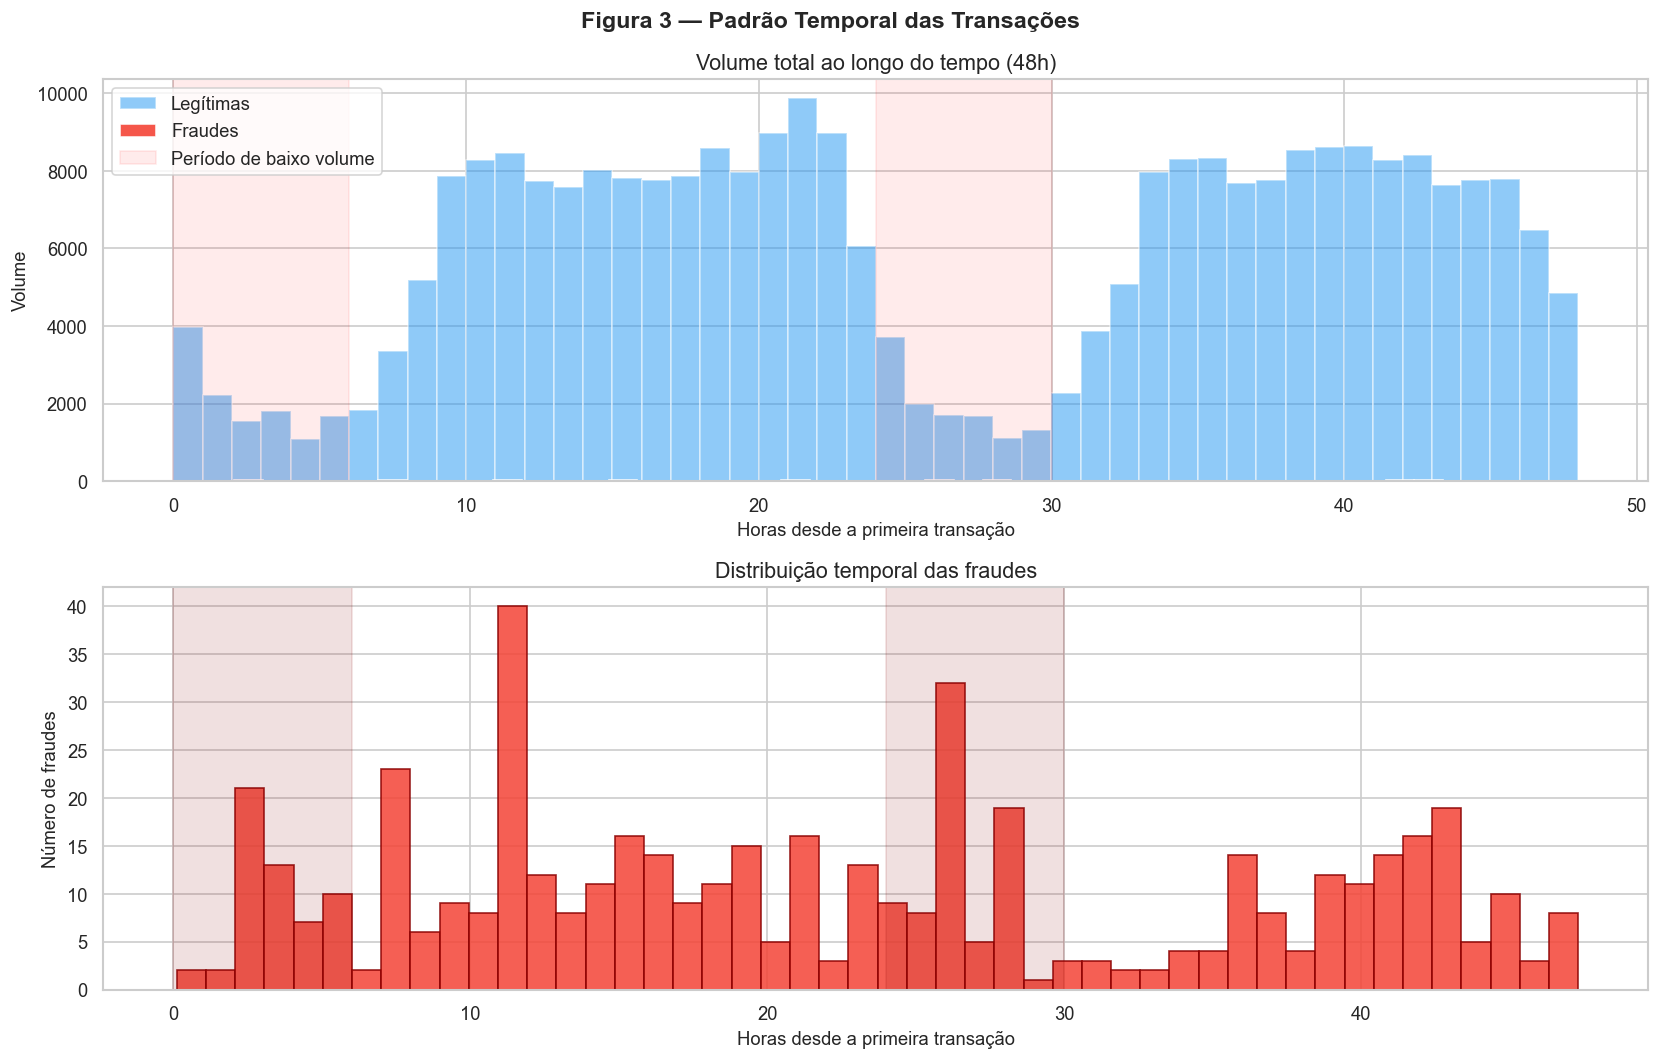

Interpretação:
  124 fraudes (25.2%) ocorrem nos períodos de baixo volume.


In [7]:
# ── Figura 3: Padrão temporal ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Figura 3 — Padrão Temporal das Transações', fontsize=14, fontweight='bold')

axes[0].hist(legitimate['Time']/3600, bins=48, color='#2196F3', alpha=0.5, label='Legítimas')
axes[0].hist(fraud['Time']/3600,      bins=48, color='#F44336', alpha=0.9, label='Fraudes')
axes[0].axvspan(0, 6,   alpha=0.08, color='red', label='Período de baixo volume')
axes[0].axvspan(24, 30, alpha=0.08, color='red')
axes[0].set_title('Volume total ao longo do tempo (48h)')
axes[0].set_xlabel('Horas desde a primeira transação')
axes[0].set_ylabel('Volume')
axes[0].legend()

axes[1].hist(fraud['Time']/3600, bins=48, color='#F44336', alpha=0.85, edgecolor='darkred')
axes[1].axvspan(0, 6,   alpha=0.12, color='darkred')
axes[1].axvspan(24, 30, alpha=0.12, color='darkred')
axes[1].set_title('Distribuição temporal das fraudes')
axes[1].set_xlabel('Horas desde a primeira transação')
axes[1].set_ylabel('Número de fraudes')

plt.tight_layout()
plt.savefig('fig3_temporal.png', bbox_inches='tight')
plt.show()

fraud_baixo_volume = fraud[(fraud['Time']/3600 < 6) | ((fraud['Time']/3600 >= 24) & (fraud['Time']/3600 < 30))]
print('Interpretação:')
print(f'  {len(fraud_baixo_volume)} fraudes ({len(fraud_baixo_volume)/len(fraud)*100:.1f}%) ocorrem nos períodos de baixo volume.')

**INTERPRETAÇÃO — Padrão Temporal das Fraudes**

  - Fraudes nos períodos de baixo volume (madrugada): 124
  - Representam 25.2% do total de fraudes

**INSIGHT**: Fraudes se concentram nos horários de MENOR volume de transações legítimas. Isso não é coincidência:

  1. Monitoramento humano é mínimo na madrugada
  2. Clientes raramente verificam extratos nesse horário
  3. O tempo de resposta para contestação é maior

**IMPLICAÇÃO OPERACIONAL**: Um sistema automatizado como o que estamos construindo é especialmente valioso nesses horários, justamente onde a vigilância humana é mais fraca.

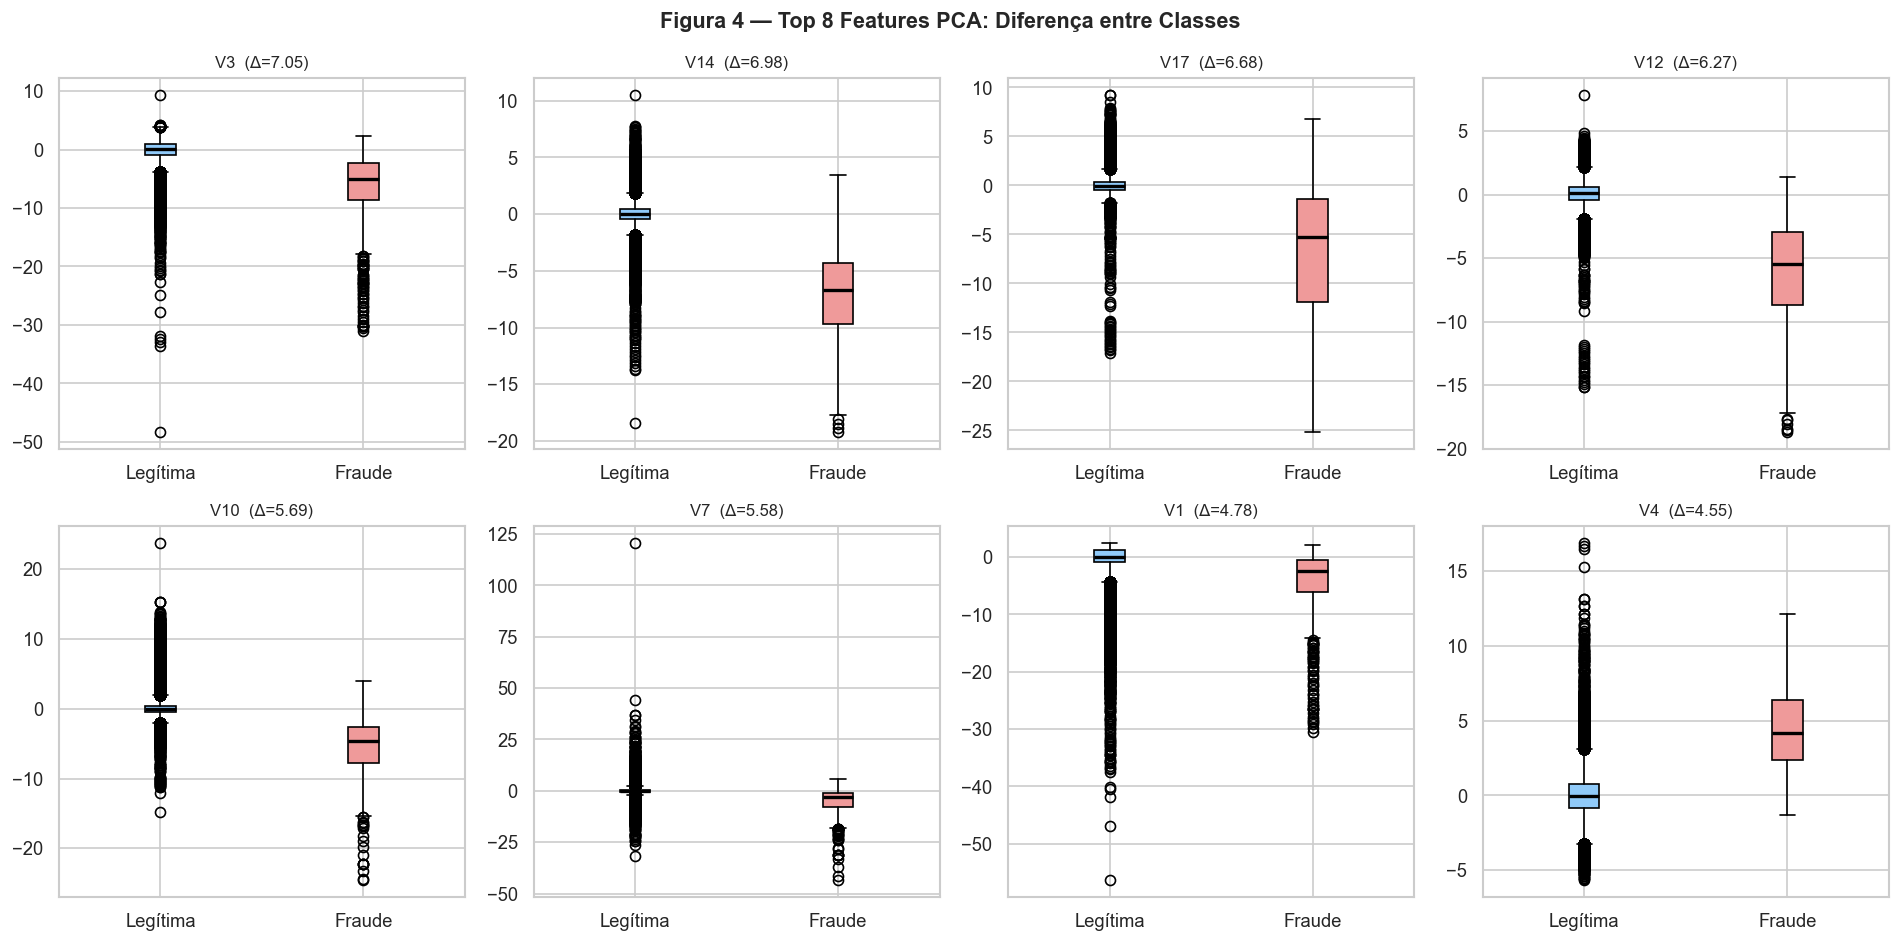

Features mais discriminativas: ['V3', 'V14', 'V17', 'V12', 'V10', 'V7', 'V1', 'V4']


In [8]:
# ── Figura 4: Top features PCA ────────────────────────────────────────────────
# Identificar as features com maior diferença de média entre classes
pca_features = [f'V{i}' for i in range(1, 29)]
mean_diff    = abs(fraud[pca_features].mean() - legitimate[pca_features].mean())
top_features = mean_diff.nlargest(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Figura 4 — Top 8 Features PCA: Diferença entre Classes', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(top_features):
    bp = axes[i].boxplot([legitimate[feat].values, fraud[feat].values],
                          patch_artist=True, labels=['Legítima', 'Fraude'],
                          medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#90CAF9')
    bp['boxes'][1].set_facecolor('#EF9A9A')
    axes[i].set_title(f'{feat}  (Δ={mean_diff[feat]:.2f})', fontsize=10)

plt.tight_layout()
plt.savefig('fig4_pca_features.png', bbox_inches='tight')
plt.show()

print(f'Features mais discriminativas: {top_features}')


**INTERPRETAÇÃO — Features PCA Mais Discriminativas**

Embora não possamos interpretar o significado real dessas variáveis (foram anonimizadas por PCA para preservar privacidade), elas representam combinações matemáticas dos dados originais (como localização, estabelecimento, histórico de compras).

Os boxplots mostram que as distribuições dessas features são claramente diferentes entre fraudes e transações legítimas, isso é exatamente o que o modelo de ML precisa para aprender a distinguir um caso do outro.

Features com maior sobreposição entre as classes são mais difíceis de separar, por isso um algoritmo poderoso como
o XGBoost é necessário para capturar as fronteiras não-lineares.

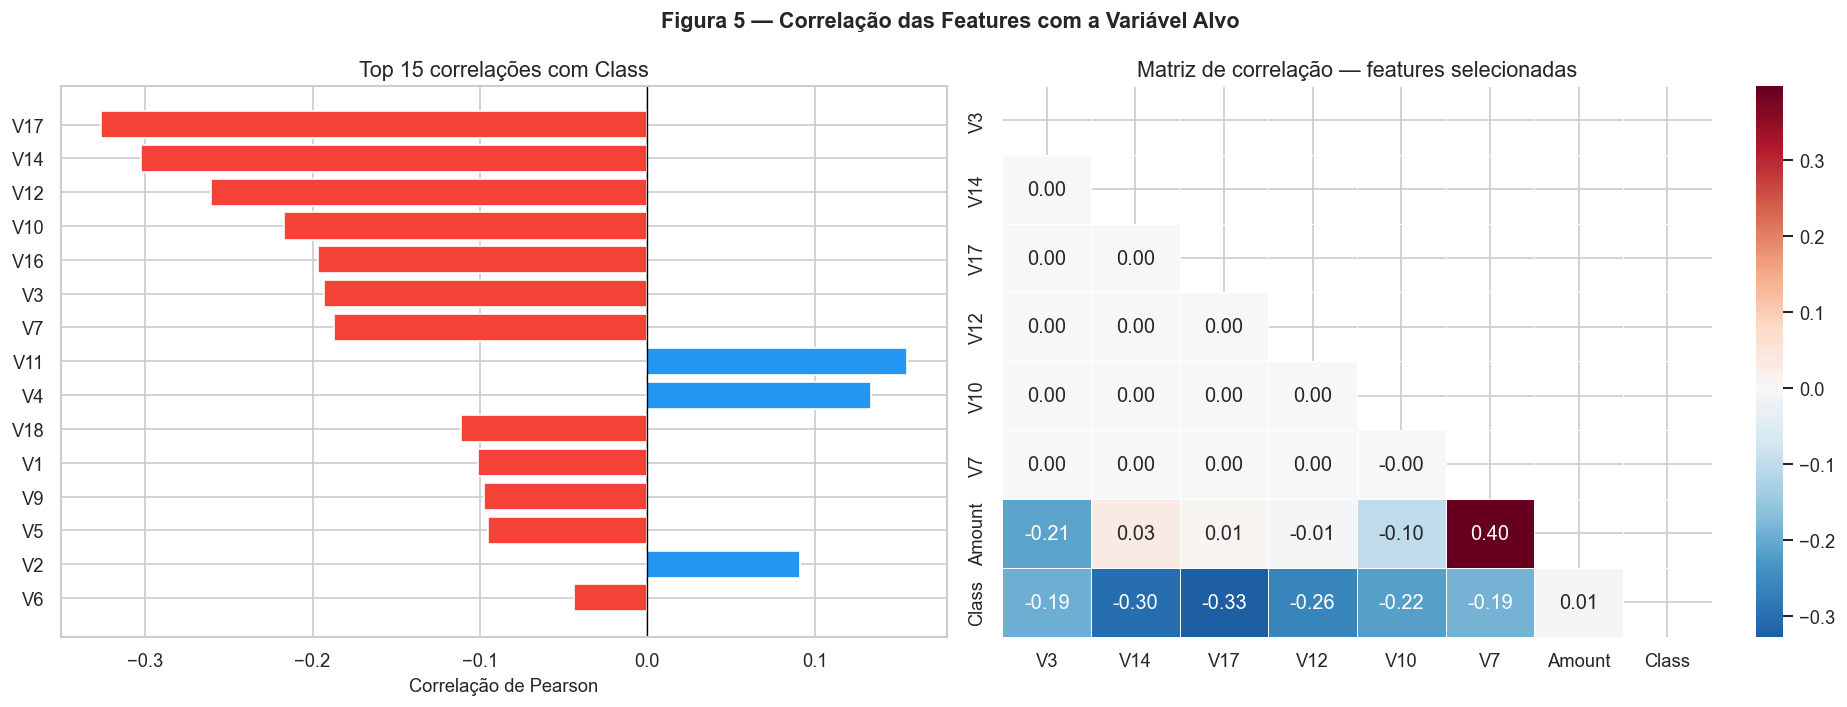

Top 5 features mais correlacionadas com fraude:
  V17  : -0.3265
  V14  : -0.3025
  V12  : -0.2606
  V10  : -0.2169
  V16  : -0.1965


In [9]:
# ── Figura 5: Correlação com Class ────────────────────────────────────────────
corr_class = df[pca_features + ['Amount', 'Time']].corrwith(df['Class']).sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figura 5 — Correlação das Features com a Variável Alvo', fontsize=13, fontweight='bold')

top15 = corr_class.head(15)

# Barplot de correlação com Class
cores_bar = ['#F44336' if v < 0 else '#2196F3' for v in top15.values]
axes[0].barh(top15.index, top15.values, color=cores_bar, edgecolor='white')
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('Top 15 correlações com Class')
axes[0].set_xlabel('Correlação de Pearson')
axes[0].invert_yaxis()

# Heatmap das top features entre si
top_corr_feats = top_features[:6] + ['Amount', 'Class']
mask = np.triu(np.ones_like(df[top_corr_feats].corr(), dtype=bool))
sns.heatmap(df[top_corr_feats].corr(), mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=axes[1], linewidths=0.5)
axes[1].set_title('Matriz de correlação — features selecionadas')

plt.tight_layout()
plt.savefig('fig5_correlacao.png', bbox_inches='tight')
plt.show()

print('Top 5 features mais correlacionadas com fraude:')
for feat, corr in corr_class.head(5).items():
    print(f'  {feat:5s}: {corr:+.4f}')

INTERPRETAÇÃO — Correlação com a Variável Alvo

O PCA garante que V1-V28 são matematicamente independentes entre si (correlação zero confirmado no heatmap).
As correlações com `Class` indicam o poder preditivo individual de cada feature. O modelo combina todas simultaneamente, capturando interações que correlações lineares não capturam.

---
## 4. 🔧 Pré-processamento

### Por que fazemos isso?
As variáveis `Time` e `Amount` estão em escalas muito diferentes das componentes V1–V28. Sem escalonamento, algoritmos sensíveis à escala atribuirão peso desproporcional a essas variáveis por magnitude numérica, não por relevância preditiva.

### Por que RobustScaler?
O StandardScaler utiliza média e desvio padrão, ambos sensíveis a valores extremos. Com `Amount` apresentando mediana de R$22 e máximo de R$25.691, o desvio padrão fica inflado e a normalização se torna distorcida. O **RobustScaler** utiliza mediana e IQR, sendo robusto a outliers. As variáveis V1–V28 já foram normalizadas pelo banco via PCA e não exigem escalonamento adicional.

### Onde será aplicado?
O scaler treinado aqui deve ser salvo e aplicado a cada nova transação em produção, antes de ser processada pelo modelo.

In [10]:
df_processed = df.copy()
scaler = RobustScaler()
df_processed[['Time', 'Amount']] = scaler.fit_transform(df_processed[['Time', 'Amount']])

print('✅ RobustScaler aplicado em Time e Amount.')
print()
print('Comparação ANTES × DEPOIS do escalonamento:')
print()
print(f'{"":12} {"Time (antes)":>15} {"Time (depois)":>15} | {"Amount (antes)":>15} {"Amount (depois)":>15}')
print('-' * 80)
for stat in ['mean', 'std', 'min', '50%', 'max']:
    print(f'{stat:12} {df["Time"].describe()[stat]:>15.2f} {df_processed["Time"].describe()[stat]:>15.4f} | '
          f'{df["Amount"].describe()[stat]:>15.2f} {df_processed["Amount"].describe()[stat]:>15.4f}')

✅ RobustScaler aplicado em Time e Amount.

Comparação ANTES × DEPOIS do escalonamento:

                Time (antes)   Time (depois) |  Amount (antes) Amount (depois)
--------------------------------------------------------------------------------
mean                94813.86          0.1189 |           88.35          0.9271
std                 47488.15          0.5579 |          250.12          3.4950
min                     0.00         -0.9950 |            0.00         -0.3074
50%                 84692.00          0.0000 |           22.00          0.0000
max                172792.00          1.0350 |        25691.16        358.6832


In [11]:
# ── Separação entre features e target ────────────────────────────────────────
X = df_processed.drop(columns=['Class'])
y = df_processed['Class']

# ── Divisão treino/teste (80/20) estratificada ────────────────────────────────
# Stratify garante que a proporção de fraudes é mantida em ambos os conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('=' * 65)
print('📂 DIVISÃO TREINO / TESTE (80% / 20%) — Estratificada')
print('=' * 65)
print(f'Treino : {X_train.shape[0]:>7,} amostras | Fraudes: {y_train.sum():>4} ({y_train.mean()*100:.3f}%)')
print(f'Teste  : {X_test.shape[0]:>7,} amostras | Fraudes: {y_test.sum():>4} ({y_test.mean()*100:.3f}%)')
print()
print('O parâmetro stratify=y garante que a proporção de fraudes (0.173%)')
print('seja mantida identicamente nos dois conjuntos — confirmado acima.')

📂 DIVISÃO TREINO / TESTE (80% / 20%) — Estratificada
Treino : 227,845 amostras | Fraudes:  394 (0.173%)
Teste  :  56,962 amostras | Fraudes:   98 (0.172%)

O parâmetro stratify=y garante que a proporção de fraudes (0.173%)
seja mantida identicamente nos dois conjuntos — confirmado acima.


**Por que estratificar?**
Sem stratify=y, uma divisão aleatória poderia por acaso colocar 90% das fraudes no treino e apenas 10% no teste. 
O parâmetro stratify garante que a proporção 0.173% de fraudes seja mantida IDENTICAMENTE nos dois conjuntos — confirmado nos números acima.

---
## 5. ⚖️ Tratamento do Desbalanceamento — SMOTETomek

### Por que fazemos isso?
Algoritmos de machine learning treinados em dados desbalanceados aprendem a ignorar a classe minoritária. 

Com 1 fraude para cada 577 transações legítimas, o modelo encontra o caminho de menor resistência: classificar tudo como legítimo e ainda assim errar menos de 0,2% das vezes. Para forçar o aprendizado dos padrões reais das fraudes, é necessário apresentar ao modelo um conjunto de treino com proporção equilibrada entre as classes.

### Estratégia adotada: SMOTETomek
Combinação de duas técnicas complementares:

- **SMOTE:** Gera amostras sintéticas da classe minoritária matematicamente possiveis e não duplica registros existentes.
- **Tomek Links:** Remove amostras da classe majoritária que estão na fronteira de decisão, limpando as zonas de multipla interpretação entre as classes

| Técnica | Limitação |
|---|---|
| Undersampling puro | Descartaria >228k transações legítimas reais |
| SMOTE puro | Pode gerar ruído nas regiões de fronteira |
| **SMOTETomek** | ✅ Equilibra sem descartar dados reais + limpa a fronteira |

> **Regra:** A reamostragem é aplicada **exclusivamente no conjunto de treino**. O conjunto de teste permanece com a distribuição original, simulando o ambiente de produção.

In [12]:
smote_tomek = SMOTETomek(random_state=RANDOM_STATE, n_jobs=-1)
X_train_res, y_train_res = smote_tomek.fit_resample(X_train, y_train)

print('=' * 65)
print('⚖️  RESULTADO DO SMOTETomek')
print('=' * 65)
print(f'Antes  : {len(X_train):>7,} amostras | Fraudes: {y_train.sum():>4} ({y_train.mean()*100:.3f}%)')
print(f'Depois : {len(X_train_res):>7,} amostras | Fraudes: {y_train_res.sum():>6,} ({y_train_res.mean()*100:.1f}%)')
print()
print(f'Amostras sintéticas geradas: ~{y_train_res.sum() - y_train.sum():,}')
print(f'Conjunto de teste (intacto): {len(X_test):,} amostras | {y_test.sum()} fraudes ({y_test.mean()*100:.3f}%)')

⚖️  RESULTADO DO SMOTETomek
Antes  : 227,845 amostras | Fraudes:  394 (0.173%)
Depois : 454,902 amostras | Fraudes: 227,451 (50.0%)

Amostras sintéticas geradas: ~227,057
Conjunto de teste (intacto): 56,962 amostras | 98 fraudes (0.172%)


---
## 6. 🤖 Modelagem Baseline

### Por que três modelos?
Cada modelo tem premissas e pontos fortes distintos. Avaliar três modelos com parâmetros padrão antes da otimização estabelece um **baseline comparativo justo**, isso permite identificar qual arquitetura melhor captura os padrões deste problema específico antes de qualquer ajuste fino.

### Estrutura da avaliação
Cada modelo é treinado nos dados balanceados (SMOTETomek) e avaliado no conjunto de teste original (distribuição real). Os resultados desta seção são **sem otimização de hiperparâmetros** servem como ponto de partida para a seção 8.

In [13]:
# ── Função utilitária para avaliação padronizada ──────────────────────────────
def avaliar_modelo(nome, modelo, X_tr, y_tr, X_te, y_te, threshold=0.5):
    """
    Treina o modelo e retorna todas as métricas de avaliação.
    threshold: ponto de corte para classificação binária (padrão=0.5)
    """
    modelo.fit(X_tr, y_tr)
    y_prob = modelo.predict_proba(X_te)[:, 1] # probabilidade de ser fraude
    y_pred = (y_prob >= threshold).astype(int)
    cm     = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        'modelo'       : nome,
        'auc_roc'      : roc_auc_score(y_te, y_prob),
        'avg_precision': average_precision_score(y_te, y_prob),
        'f1'           : f1_score(y_te, y_pred),
        'recall'       : recall_score(y_te, y_pred),
        'precision'    : precision_score(y_te, y_pred),
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'y_prob': y_prob, 'y_pred': y_pred,
        'objeto': modelo
    }

CUSTO_FN = df[df['Class']==1]['Amount'].mean()  # custo médio por fraude não detectada
CUSTO_FP = 15.00                                # Estimativa ilustrativa (custo de análise manual).
                                                # Valor real deve ser fornecido pelo banco considerando:
                                                # custo do analista por hora, atendimento ao cliente e risco de churn.
                                                # Impacto no modelo vencedor: 5 FP × R$15 = R$75 (<3% do custo total).

print('✅ Função de avaliação definida.')
print(f'   Premissas financeiras: FN=R${CUSTO_FN:.2f}/fraude | FP=R${CUSTO_FP:.2f}/análise')

✅ Função de avaliação definida.
   Premissas financeiras: FN=R$122.21/fraude | FP=R$15.00/análise


In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# MODELO 1 BASELINE: Regressão Logística
# ────────────────────────────────────────────────────────────────────────────
# Modelo linear com alta interpretabilidade. Utilizado como baseline de
# referência. Em caso de modelos mais complexos não o superarem de forma significativa,
# a complexidade adicional não se justifica.
# class_weight='balanced': penaliza proporcionalmente erros na classe minoritária.

print('⏳ [1/3] Treinando Regressão Logística (baseline)...')
lr_base = LogisticRegression(
    max_iter=1000, class_weight='balanced',
    random_state=RANDOM_STATE, solver='lbfgs', n_jobs=-1
)
res_lr_base = avaliar_modelo('Regressão Logística', lr_base, X_train_res, y_train_res, X_test, y_test)

print(f'\n📊 Regressão Logística (baseline) — Resultados no Teste:')
print(f'   AUC-ROC  : {res_lr_base["auc_roc"]:.4f}')
print(f'   F1-Score : {res_lr_base["f1"]:.4f}')
print(f'   Recall   : {res_lr_base["recall"]:.4f}  → detectou {res_lr_base["tp"]} de {res_lr_base["tp"]+res_lr_base["fn"]} fraudes')
print(f'   Precision: {res_lr_base["precision"]:.4f}')
print()
print('\n' + classification_report(y_test, res_lr_base['y_pred'], target_names=['Legítima', 'Fraude']))

⏳ [1/3] Treinando Regressão Logística (baseline)...

📊 Regressão Logística (baseline) — Resultados no Teste:
   AUC-ROC  : 0.9712
   F1-Score : 0.1110
   Recall   : 0.9184  → detectou 90 de 98 fraudes
   Precision: 0.0591


              precision    recall  f1-score   support

    Legítima       1.00      0.97      0.99     56864
      Fraude       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



**Resultados da Regressão logistica - Recall alto mas F1 baixo:**


O modelo detectou 90 fraudes (91.8%),
porém para isso bloqueou 1434 transações LEGÍTIMAS.
De cada 10 alertas emitidos, apenas 0.6 seriam fraude real.
Isso inundaria a equipe de análise com falsos alarmes. O que seria inviável operacionalmente.

In [15]:
# ────────────────────────────────────────────────────────────────────────────
# MODELO 2 BASELINE: Random Forest
# ────────────────────────────────────────────────────────────────────────────
# Ensemble de árvores de decisão que combina múltiplos classificadores fracos
# para formar um modelo robusto. Naturalmente resistente a overfitting e
# capaz de capturar relações não-lineares entre as features.
# class_weight='balanced_subsample': ajusta os pesos por classe em cada
# subconjunto de treino, reforçando a detecção da classe minoritária.

print('⏳ [2/3] Treinando Random Forest (baseline)...')
rf_base = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE, n_jobs=-1
)
res_rf_base = avaliar_modelo('Random Forest', rf_base, X_train_res, y_train_res, X_test, y_test)

print(f'\n📊 Random Forest (baseline) — Resultados no Teste:')
print(f'   AUC-ROC  : {res_rf_base["auc_roc"]:.4f}')
print(f'   F1-Score : {res_rf_base["f1"]:.4f}')
print(f'   Recall   : {res_rf_base["recall"]:.4f}  → detectou {res_rf_base["tp"]} de {res_rf_base["tp"]+res_rf_base["fn"]} fraudes')
print(f'   Precision: {res_rf_base["precision"]:.4f}')
print()
print('\n' + classification_report(y_test, res_rf_base['y_pred'], target_names=['Legítima', 'Fraude']))

⏳ [2/3] Treinando Random Forest (baseline)...

📊 Random Forest (baseline) — Resultados no Teste:
   AUC-ROC  : 0.9759
   F1-Score : 0.7867
   Recall   : 0.8469  → detectou 83 de 98 fraudes
   Precision: 0.7345


              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     56864
      Fraude       0.73      0.85      0.79        98

    accuracy                           1.00     56962
   macro avg       0.87      0.92      0.89     56962
weighted avg       1.00      1.00      1.00     56962



**Resultados do Random Forest — Equilíbrio sólido entre detecção e precisão:**

O modelo detectou 83 fraudes (84.7%),
bloqueando apenas 30 transações LEGÍTIMAS para isso.
De cada 10 alertas emitidos, 7.3 seriam fraude real.
Esse equilíbrio é operacionalmente viável, em uma operação real, a equipe de análise
recebe uma fila enxuta e com alta taxa de acerto.

In [16]:
# ────────────────────────────────────────────────────────────────────────────
# MODELO 3 BASELINE: XGBoost
# ────────────────────────────────────────────────────────────────────────────
# Gradient boosting que constrói árvores sequencialmente, onde cada nova
# árvore corrige os erros da anterior. Estado da arte para dados tabulares.
# scale_pos_weight: informa ao algoritmo a razão entre as classes,
# aumentando a penalização por erros na classe minoritária.

scale_pw = int(class_counts[0] / class_counts[1])
print(f'⚙️  scale_pos_weight = {scale_pw}')
print('⏳ [3/3] Treinando XGBoost (baseline)...')
xgb_base = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pw,
    use_label_encoder=False, eval_metric='aucpr',
    random_state=RANDOM_STATE, n_jobs=-1
)
res_xgb_base = avaliar_modelo('XGBoost', xgb_base, X_train_res, y_train_res, X_test, y_test)

print(f'\n📊 XGBoost (baseline) — Resultados no Teste:')
print(f'   AUC-ROC  : {res_xgb_base["auc_roc"]:.4f}')
print(f'   F1-Score : {res_xgb_base["f1"]:.4f}')
print(f'   Recall   : {res_xgb_base["recall"]:.4f}  → detectou {res_xgb_base["tp"]} de {res_xgb_base["tp"]+res_xgb_base["fn"]} fraudes')
print(f'   Precision: {res_xgb_base["precision"]:.4f}')
print()
print('\n' + classification_report(y_test, res_xgb_base['y_pred'], target_names=['Legítima', 'Fraude']))

⚙️  scale_pos_weight = 577
⏳ [3/3] Treinando XGBoost (baseline)...

📊 XGBoost (baseline) — Resultados no Teste:
   AUC-ROC  : 0.9779
   F1-Score : 0.2080
   Recall   : 0.8980  → detectou 88 de 98 fraudes
   Precision: 0.1176


              precision    recall  f1-score   support

    Legítima       1.00      0.99      0.99     56864
      Fraude       0.12      0.90      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.60     56962
weighted avg       1.00      0.99      0.99     56962



**Resultados do XGBoost base — Recall alto, mas precisão crítica:**

O modelo detectou 88 fraudes (89.8%),
porém para isso bloqueou 660 transações LEGÍTIMAS.
De cada 10 alertas emitidos, apenas 1.2 seriam fraude real.
O parâmetro scale_pos_weight=577 foi agressivo demais e 
o modelo está com excesso de cautela, indicando frudes em demasia,
gerando um volume de falsos alarmes próximo ao da Regressão Logística.
Isso reforça a necessidade de otimização de hiperparâmetros na próxima etapa.

---
## 7. 📊 Comparação Baseline

### Por que fazemos isso?
A comparação dos três modelos sem otimização estabelece uma linha de base que será utilizada como referência para mensurar o ganho obtido pela otimização de hiperparâmetros na seção seguinte. Ela também evidencia qual arquitetura parte de uma posição mais favorável antes do ajuste fino.

### Glossário de métricas

| Métrica | O que significa no contexto do banco |
|---|---|
| **Recall** | % das fraudes reais que o modelo detectou. *Prioridade máxima.* |
| **Precision** | De cada alerta emitido, quantos % são fraude real |
| **F1-Score** | Equilíbrio entre Recall e Precision |
| **AUC-ROC** | Capacidade geral de distinguir fraude de legítima (0.5=aleatório, 1.0=perfeito) |
| **Falso Negativo** | Fraude que passou. **Custo: prejuízo financeiro + reembolso + reputação** |
| **Falso Positivo** | Cliente legítimo bloqueado. Custo: insatisfação + possível churn |

In [17]:
baseline_resultados = [res_lr_base, res_rf_base, res_xgb_base]

df_baseline = pd.DataFrame([
    {
        'Modelo'               : r['modelo'],
        'AUC-ROC'              : round(r['auc_roc'], 4),
        'F1-Score'             : round(r['f1'], 4),
        'Recall'               : round(r['recall'], 4),
        'Precision'            : round(r['precision'], 4),
        'Fraudes detectadas'   : f"{r['tp']}/{r['tp']+r['fn']}",
        'Falsos Positivos'     : r['fp'],
        'Custo est. (R$)'      : round(r['fn']*CUSTO_FN + r['fp']*CUSTO_FP, 2)
    }
    for r in baseline_resultados
]).set_index('Modelo')

print('=' * 78)
print('📊 COMPARAÇÃO BASELINE — 3 MODELOS (parâmetros padrão)')
print('=' * 78)
print(df_baseline.to_string())
print()
melhor_base = df_baseline['F1-Score'].idxmax()
print(f'Melhor modelo baseline por F1-Score: {melhor_base} ({df_baseline.loc[melhor_base, "F1-Score"]})')

📊 COMPARAÇÃO BASELINE — 3 MODELOS (parâmetros padrão)
                     AUC-ROC  F1-Score  Recall  Precision Fraudes detectadas  Falsos Positivos  Custo est. (R$)
Modelo                                                                                                         
Regressão Logística   0.9712    0.1110  0.9184     0.0591              90/98              1434         22487.69
Random Forest         0.9759    0.7867  0.8469     0.7345              83/98                30          2283.17
XGBoost               0.9779    0.2080  0.8980     0.1176              88/98               660         11122.11

Melhor modelo baseline por F1-Score: Random Forest (0.7867)


**Conclusão do baseline:**

O **Random Forest** apresentou o melhor equilíbrio entre detecção de fraudes
e controle de falsos positivos. Regressão Logística e XGBoost base
demonstraram recall elevado, mas com volume de falsos alarmes inviável
operacionalmente. Os três modelos serão otimizados na seção 8 para uma
comparação justa entre seus desempenhos máximos.

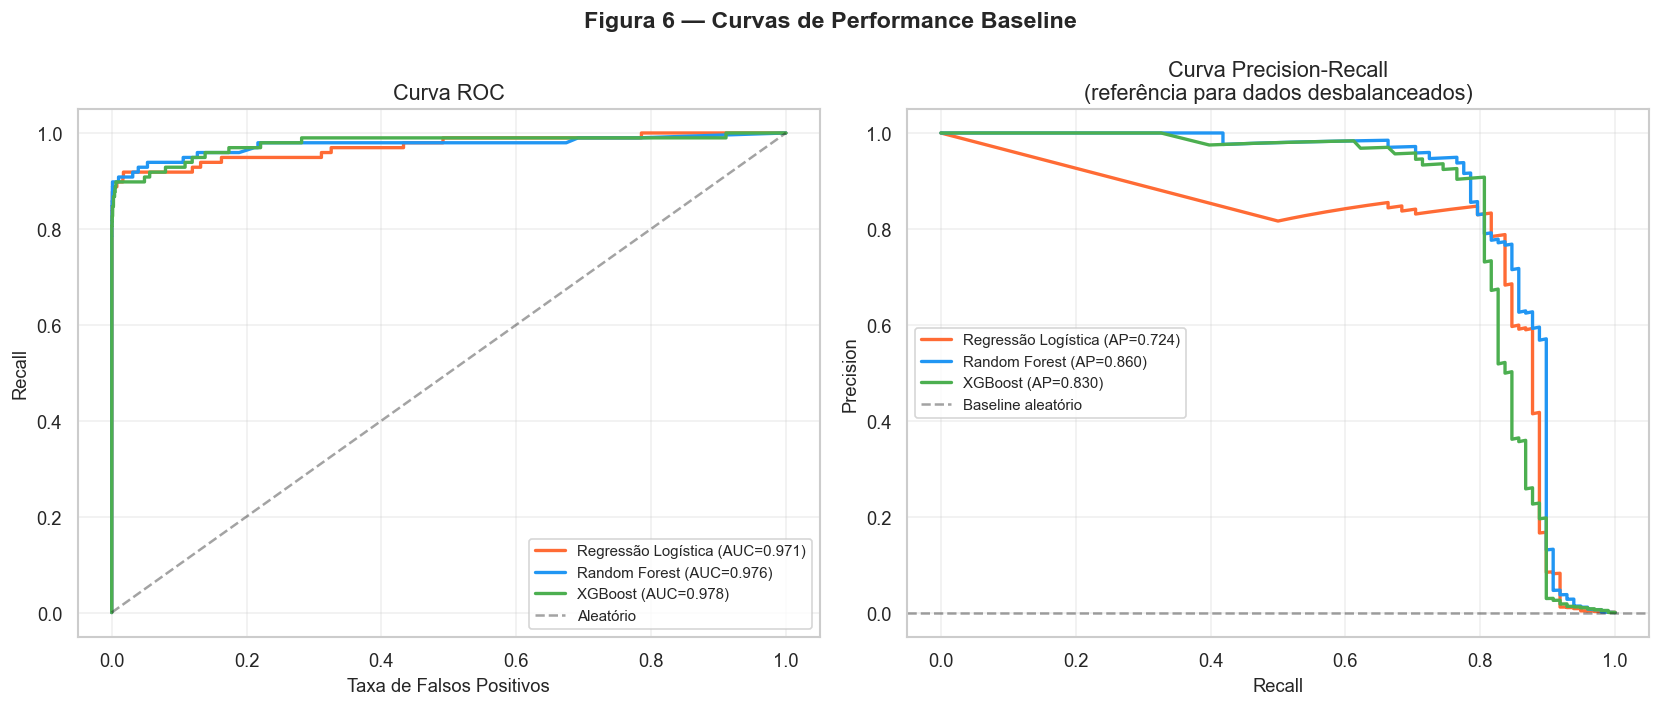

In [18]:
# ── Figura 6: Curvas baseline ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figura 6 — Curvas de Performance Baseline', fontsize=14, fontweight='bold')

cores = {'Regressão Logística': '#FF6B35', 'Random Forest': '#2196F3', 'XGBoost': '#4CAF50'}

for r in baseline_resultados:
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    axes[0].plot(fpr, tpr, label=f"{r['modelo']} (AUC={r['auc_roc']:.3f})",
                 color=cores[r['modelo']], linewidth=2)
axes[0].plot([0,1],[0,1],'k--', alpha=0.4, label='Aleatório')
axes[0].set_xlabel('Taxa de Falsos Positivos')
axes[0].set_ylabel('Recall')
axes[0].set_title('Curva ROC')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

for r in baseline_resultados:
    prec, rec, _ = precision_recall_curve(y_test, r['y_prob'])
    axes[1].plot(rec, prec, label=f"{r['modelo']} (AP={r['avg_precision']:.3f})",
                 color=cores[r['modelo']], linewidth=2)
axes[1].axhline(y=class_counts[1]/len(df), color='k', linestyle='--', alpha=0.4, label='Baseline aleatório')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall\n(referência para dados desbalanceados)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig6_baseline_curvas.png', bbox_inches='tight')
plt.show()

**INTERPRETAÇÃO — Curvas de Performance**


Curva ROC: Todos os modelos têm AUC > 0.97. Excelente capacidade
discriminativa geral. Mas ROC pode ser enganosa para dados muito
desbalanceados, pois é influenciada pelos 56.864 negativos verdadeiros.

Curva Precision-Recall: Esta é a métrica mais honesta para o nosso
caso. Mostra que o Random Forest tem o melhor equilíbrio entre
detectar fraudes e evitar falsos alarmes, confirmado pelo AP mais alto.

---
## 8. 🎛️ Otimização de Hiperparâmetros — Três Modelos

### Por que fazemos isso?
Os resultados da seção 7 refletem cada modelo com configurações padrão, não necessariamente adequadas para este problema específico. Comparar modelos sem otimização equivale a avaliá-los em condições desiguais. Otimizar os três garante que a comparação final reflita o desempenho máximo de cada arquitetura.

### Método: RandomizedSearchCV com StratifiedKFold
Em vez de testar todas as combinações possíveis (Grid Search, que é computacionalmente inviável), testamos **15 combinações aleatórias** do espaço de parâmetros. Cada combinação é avaliada com **validação cruzada estratificada
de 3 folds**, garantindo robustez estatística na seleção. A métrica de otimização é o **F1-Score**.

### Escopo da otimização por modelo
- **Regressão Logística:** Otimização leve (espaço reduzido). Mantida como referência de baseline, sua limitação estrutural (modelo linear para problema não-linear) dificilmente será resolvida por hiperparâmetros
- **Random Forest:** Otimização completa apartir do ponto em que se tornou o candidato principal com base no baseline
- **XGBoost:** Otimização completa pois candidato principal a ser comparado com Random Forest otimizado

In [19]:
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# ────────────────────────────────────────────────────────────────────────────
# OTIMIZAÇÃO 1: Regressão Logística
# ────────────────────────────────────────────────────────────────────────────
print('⏳ [1/3] Otimizando Regressão Logística...')

param_lr = {
    'C'           : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty'     : ['l1', 'l2'],
    'solver'      : ['liblinear', 'saga'],
    'class_weight': ['balanced']
}

rscv_lr = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_distributions=param_lr, n_iter=15,
    scoring='f1', cv=cv_strategy, n_jobs=-1,
    random_state=RANDOM_STATE, verbose=0
)
rscv_lr.fit(X_train_res, y_train_res)
res_lr_opt = avaliar_modelo('Regressão Logística Otimizada', rscv_lr.best_estimator_,
                             X_train_res, y_train_res, X_test, y_test)

print(f'   Melhor F1 no CV: {rscv_lr.best_score_:.4f}')
print(f'   Melhores parâmetros: {rscv_lr.best_params_}')
print(f'   F1 no teste: {res_lr_opt["f1"]:.4f}  (baseline: {res_lr_base["f1"]:.4f})')
ganho_lr = (res_lr_opt['f1'] - res_lr_base['f1']) * 100
print(f'   Ganho com otimização: {ganho_lr:+.2f} pontos percentuais')

⏳ [1/3] Otimizando Regressão Logística...
   Melhor F1 no CV: 0.9526
   Melhores parâmetros: {'solver': 'liblinear', 'penalty': 'l2', 'class_weight': 'balanced', 'C': 10}
   F1 no teste: 0.1108  (baseline: 0.1110)
   Ganho com otimização: -0.01 pontos percentuais


**Regressão Logística Otimizada — Resultado da Otimização:**

A otimização de hiperparâmetros **não produziu ganho mensurável** para este modelo: 
- F1 de 0.1110 no baseline contra 0.1108 após otimização (variação de -0.01 pp). 

Esse resultado confirma a limitação estrutural da Regressão Logística para este problema. Sendo um modelo linear, não consegue capturar as fronteiras de decisão não-lineares que separam fraudes de transações legítimas. Sua função neste projeto se encerra como referência de baseline.

In [20]:
# ────────────────────────────────────────────────────────────────────────────
# OTIMIZAÇÃO 2: Random Forest
# ────────────────────────────────────────────────────────────────────────────
print('⏳ [2/3] Otimizando Random Forest (pode levar alguns minutos)...')

param_rf = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features'    : ['sqrt', 'log2', 0.3],
    'class_weight'    : ['balanced', 'balanced_subsample']
}

rscv_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_rf, n_iter=15,
    scoring='f1', cv=cv_strategy, n_jobs=-1,
    random_state=RANDOM_STATE, verbose=1
)
rscv_rf.fit(X_train_res, y_train_res)
res_rf_opt = avaliar_modelo('Random Forest Otimizado', rscv_rf.best_estimator_,
                             X_train_res, y_train_res, X_test, y_test)

print(f'\n   Melhor F1 no CV: {rscv_rf.best_score_:.4f}')
print(f'   Melhores parâmetros: {rscv_rf.best_params_}')
print(f'   F1 no teste: {res_rf_opt["f1"]:.4f}  (baseline: {res_rf_base["f1"]:.4f})')
ganho_rf = (res_rf_opt['f1'] - res_rf_base['f1']) * 100
print(f'   Ganho com otimização: {ganho_rf:+.2f} pontos percentuais')

⏳ [2/3] Otimizando Random Forest (pode levar alguns minutos)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

   Melhor F1 no CV: 0.9999
   Melhores parâmetros: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced'}
   F1 no teste: 0.8497  (baseline: 0.7867)
   Ganho com otimização: +6.30 pontos percentuais


**Random Forest Otimizado — Resultado da Otimização:**

A otimização produziu **ganho de +6.30 pp no F1-Score** (0.7867 → 0.8497).

Os parâmetros encontrados indicam que o modelo se beneficia de árvores sem limite de profundidade (max_depth=None), divisões mais conservadoras (min_samples_split=10) e seleção de features por log2 que reduz a variância do ensemble e melhora a generalização.

O F1 de 0.9999 no CV sobre o dataset balanceado indica ajuste quase perfeito ao treino. A queda para 0.8497 no teste é esperada e saudável ja que o modelo aprendeu os padrões reais, com alguma influência das amostras sintéticas geradas pelo SMOTE.

In [21]:
# ────────────────────────────────────────────────────────────────────────────
# OTIMIZAÇÃO 3: XGBoost
# ────────────────────────────────────────────────────────────────────────────
print('⏳ [3/3] Otimizando XGBoost (pode levar alguns minutos)...')

param_xgb = {
    'n_estimators'    : [200, 300, 400],
    'max_depth'       : [4, 5, 6, 7],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma'           : [0, 0.1, 0.3]
}

rscv_xgb = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pw, use_label_encoder=False,
                  eval_metric='aucpr', random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_xgb, n_iter=15,
    scoring='f1', cv=cv_strategy, n_jobs=-1,
    random_state=RANDOM_STATE, verbose=1
)
rscv_xgb.fit(X_train_res, y_train_res)
res_xgb_opt = avaliar_modelo('XGBoost Otimizado', rscv_xgb.best_estimator_,
                              X_train_res, y_train_res, X_test, y_test)

print(f'\n   Melhor F1 no CV: {rscv_xgb.best_score_:.4f}')
print(f'   Melhores parâmetros: {rscv_xgb.best_params_}')
print(f'   F1 no teste: {res_xgb_opt["f1"]:.4f}  (baseline: {res_xgb_base["f1"]:.4f})')
ganho_xgb = (res_xgb_opt['f1'] - res_xgb_base['f1']) * 100
print(f'   Ganho com otimização: {ganho_xgb:+.2f} pontos percentuais')

⏳ [3/3] Otimizando XGBoost (pode levar alguns minutos)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

   Melhor F1 no CV: 0.9994
   Melhores parâmetros: {'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 0.8}
   F1 no teste: 0.7257  (baseline: 0.2080)
   Ganho com otimização: +51.77 pontos percentuais


**XGBoost Otimizado — Resultado da Otimização:**

O **XGBoost foi o modelo que mais se beneficiou da otimização:** ganho de +51.77 pp no F1-Score (0.2080 → 0.7257). O baseline era prejudicado pelo scale_pos_weight=577 aplicado de forma fixa. Com a otimização, os demais hiperparâmetros (learning_rate=0.2, max_depth=7, subsample=0.9) compensaram parcialmente esse comportamento agressivo.

Ainda assim, o XGBoost otimizado (F1=0.7257) não superou o Random Forest
otimizado (F1=0.8497), que avança como modelo vencedor.

---
## 9. 🏆 Comparação Final — Modelos Otimizados

### Por que fazemos isso?
Com os três modelos operando em suas configurações otimizadas, esta seção realiza a comparação definitiva. O modelo com melhor desempenho no conjunto de teste avança para a validação final na seção 10.

In [22]:
otimizados = [res_lr_opt, res_rf_opt, res_xgb_opt]

df_final = pd.DataFrame([
    {
        'Modelo'             : r['modelo'],
        'AUC-ROC'            : round(r['auc_roc'], 4),
        'F1-Score'           : round(r['f1'], 4),
        'Recall'             : round(r['recall'], 4),
        'Precision'          : round(r['precision'], 4),
        'Fraudes detectadas' : f"{r['tp']}/{r['tp']+r['fn']}",
        'Falsos Positivos'   : r['fp'],
        'Custo est. (R$)'    : round(r['fn']*CUSTO_FN + r['fp']*CUSTO_FP, 2)
    }
    for r in otimizados
]).set_index('Modelo')

print('=' * 78)
print('🏆 COMPARAÇÃO FINAL — MODELOS OTIMIZADOS')
print('=' * 78)
print(df_final.to_string())
print()

# Evolução baseline → otimizado
print('─' * 78)
print('Evolução: Baseline → Otimizado')
print('─' * 78)
pares = [(res_lr_base, res_lr_opt), (res_rf_base, res_rf_opt), (res_xgb_base, res_xgb_opt)]
for base, opt in pares:
    delta = (opt['f1'] - base['f1']) * 100
    print(f"  {base['modelo']:22s}: F1 {base['f1']:.4f} → {opt['f1']:.4f}  ({delta:+.2f} pp)")
print()

vencedor_nome = df_final['F1-Score'].idxmax()
vencedor_f1   = df_final['F1-Score'].max()
print(f'✅ MODELO VENCEDOR: {vencedor_nome}')
print(f'   F1-Score: {vencedor_f1:.4f} | Avança para validação final (Seção 10)')

🏆 COMPARAÇÃO FINAL — MODELOS OTIMIZADOS
                               AUC-ROC  F1-Score  Recall  Precision Fraudes detectadas  Falsos Positivos  Custo est. (R$)
Modelo                                                                                                                   
Regressão Logística Otimizada   0.9714    0.1108  0.9184     0.0590              90/98              1436         22517.69
Random Forest Otimizado         0.9697    0.8497  0.8367     0.8632              82/98                13          2150.38
XGBoost Otimizado               0.9763    0.7257  0.8776     0.6187              86/98                53          2261.54

──────────────────────────────────────────────────────────────────────────────
Evolução: Baseline → Otimizado
──────────────────────────────────────────────────────────────────────────────
  Regressão Logística   : F1 0.1110 → 0.1108  (-0.01 pp)
  Random Forest         : F1 0.7867 → 0.8497  (+6.30 pp)
  XGBoost               : F1 0.2080 → 0.7257  

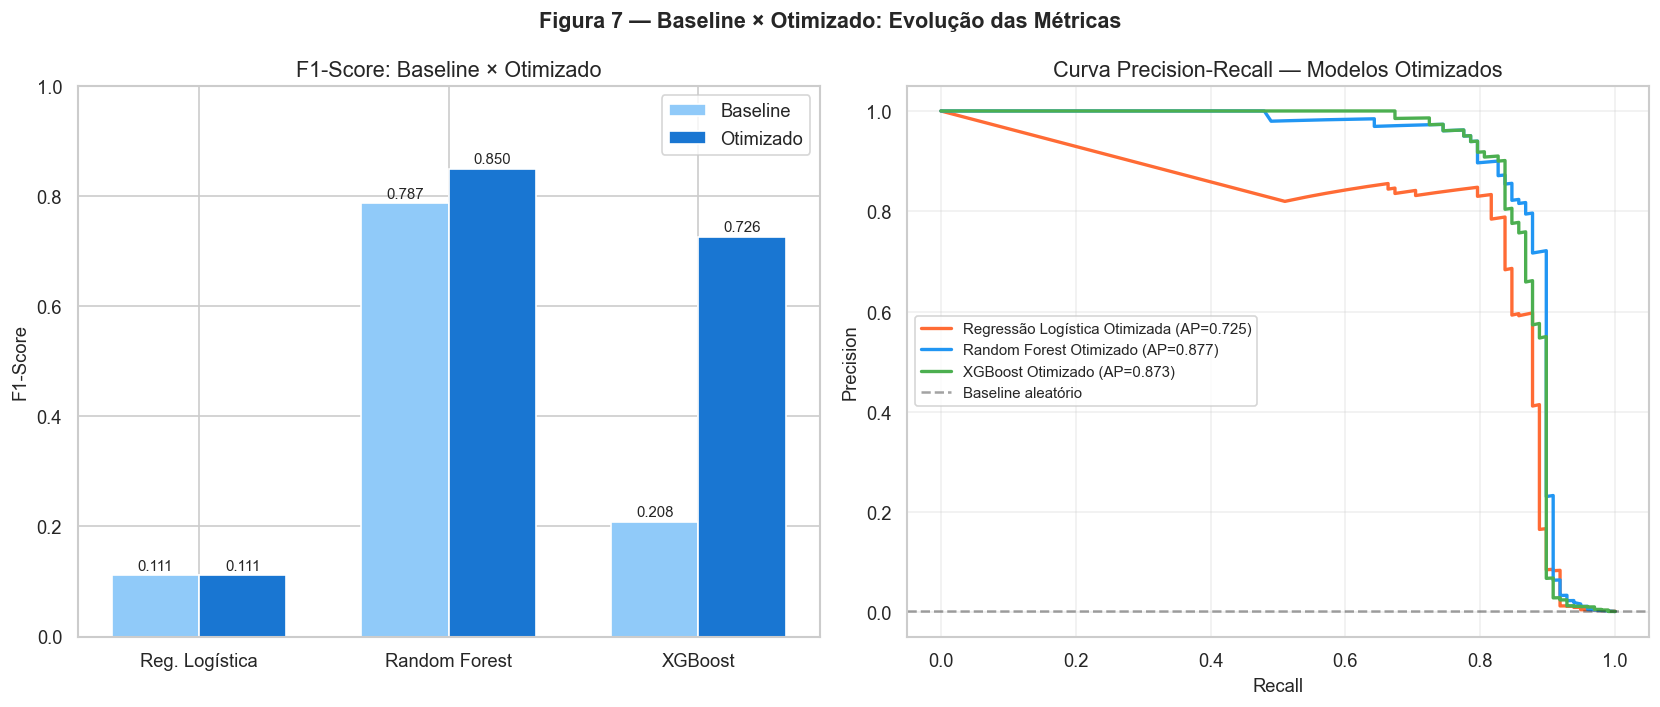

In [23]:
# ── Figura 7: Comparação visual baseline × otimizado ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figura 7 — Baseline × Otimizado: Evolução das Métricas', fontsize=13, fontweight='bold')

modelos_nomes = ['Reg. Logística', 'Random Forest', 'XGBoost']
f1_base_vals  = [res_lr_base['f1'], res_rf_base['f1'], res_xgb_base['f1']]
f1_opt_vals   = [res_lr_opt['f1'],  res_rf_opt['f1'],  res_xgb_opt['f1']]

x = np.arange(len(modelos_nomes))
w = 0.35
axes[0].bar(x - w/2, f1_base_vals, w, label='Baseline', color='#90CAF9', edgecolor='white')
axes[0].bar(x + w/2, f1_opt_vals,  w, label='Otimizado', color='#1976D2', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos_nomes)
axes[0].set_ylabel('F1-Score')
axes[0].set_title('F1-Score: Baseline × Otimizado')
axes[0].legend()
axes[0].set_ylim(0, 1)
for i, (b, o) in enumerate(zip(f1_base_vals, f1_opt_vals)):
    axes[0].text(i-w/2, b+0.01, f'{b:.3f}', ha='center', fontsize=9)
    axes[0].text(i+w/2, o+0.01, f'{o:.3f}', ha='center', fontsize=9)

# Curvas PR dos otimizados
cores_opt = ['#FF6B35', '#2196F3', '#4CAF50']
for r, cor in zip(otimizados, cores_opt):
    prec, rec, _ = precision_recall_curve(y_test, r['y_prob'])
    axes[1].plot(rec, prec, label=f"{r['modelo']} (AP={r['avg_precision']:.3f})",
                 color=cor, linewidth=2)
axes[1].axhline(y=class_counts[1]/len(df), color='k', linestyle='--', alpha=0.4, label='Baseline aleatório')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall — Modelos Otimizados')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig7_comparacao_final.png', bbox_inches='tight')
plt.show()

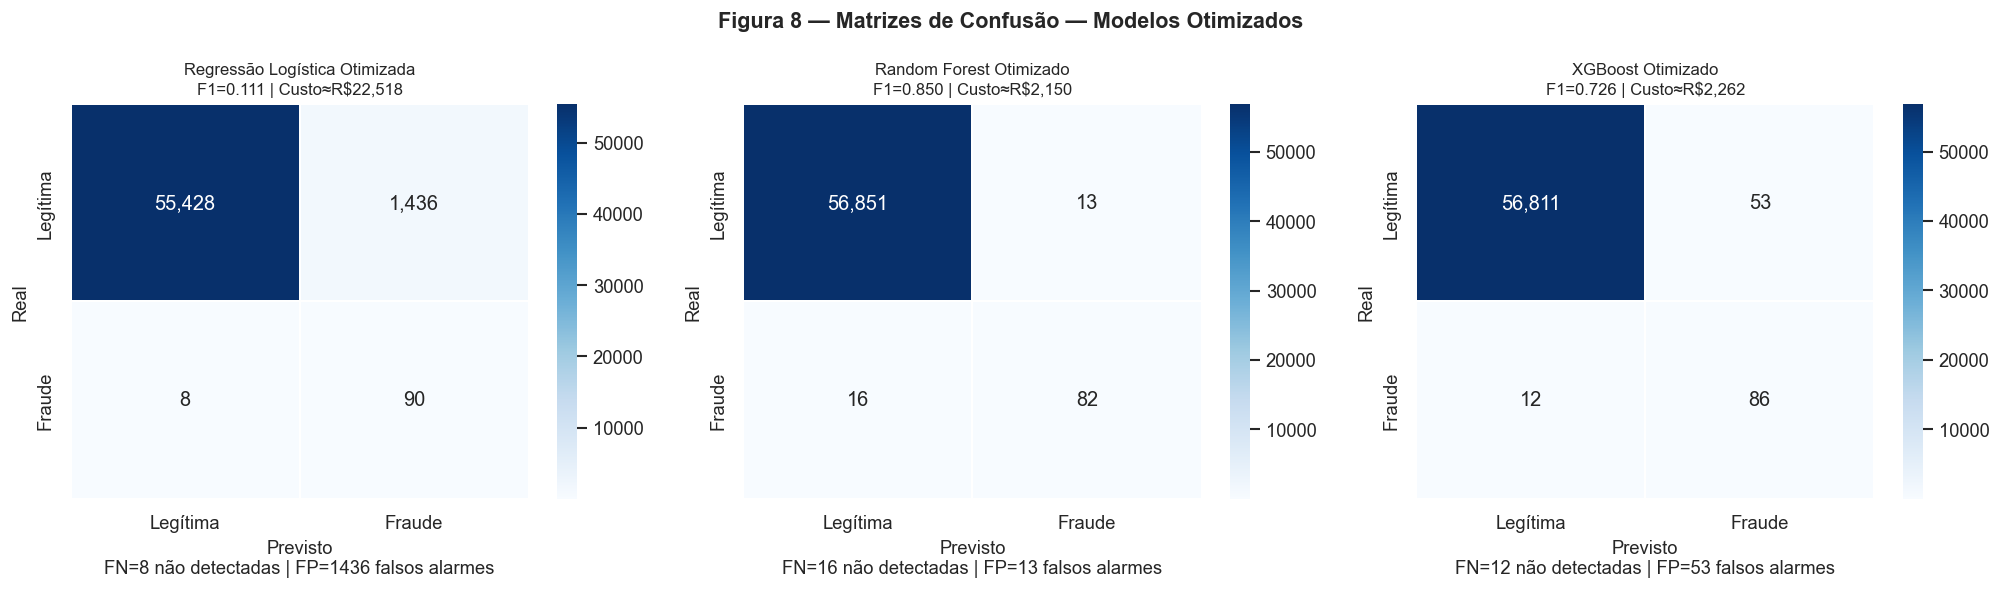

In [24]:
# ── Figura 8: Matrizes de confusão — otimizados ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Figura 8 — Matrizes de Confusão — Modelos Otimizados', fontsize=13, fontweight='bold')

for ax, r in zip(axes, otimizados):
    cm_ = confusion_matrix(y_test, r['y_pred'])
    tn_, fp_, fn_, tp_ = cm_.ravel()
    custo = fn_*CUSTO_FN + fp_*CUSTO_FP
    sns.heatmap(cm_, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Legítima', 'Fraude'],
                yticklabels=['Legítima', 'Fraude'],
                linewidths=1, linecolor='white')
    ax.set_title(f'{r["modelo"]}\nF1={r["f1"]:.3f} | Custo≈R${custo:,.0f}', fontsize=10)
    ax.set_ylabel('Real')
    ax.set_xlabel(f'Previsto\nFN={fn_} não detectadas | FP={fp_} falsos alarmes')

plt.tight_layout()
plt.savefig('fig8_confusion_otimizados.png', bbox_inches='tight')
plt.show()

**Interpretação da Comparação Final:**

Após a otimização, o Random Forest consolidou sua posição de melhor modelo com F1 de 0.8497. Detectando 82 das 98 fraudes com apenas 13 falsos alarmes e custo estimado de R$2.150,38. 

O XGBoost otimizado, apesar do ganho expressivo de +51.77 pp, ficou 12 pontos percentuais abaixo no F1-Score, com 53 falsos alarmes e custo ligeiramente superior.

O resultado da Regressão Logística confirma que a otimização de hiperparâmetros não substitui a adequação do algoritmo ao problema. Um modelo linear não tem capacidade estrutural para capturar as fronteiras não-lineares presentes nos dados de fraude.

**Random Forest Otimizado é o modelo selecionado para produção.**

---
## 10. ✅ Validação Final — Modelo Vencedor

### Por que fazemos isso?
Esta seção aplica análises complementares exclusivamente ao modelo vencedor da comparação final: importância das features, análise de threshold de decisão e resultado consolidado com impacto financeiro estimado.

### Onde será aplicado?
Os resultados desta seção compõem o relatório final e definem os parâmetros de operação do modelo em produção.

In [25]:
# Seleciona automaticamente o modelo vencedor por F1-Score
vencedor = max(otimizados, key=lambda r: r['f1'])
modelo_vencedor   = vencedor['objeto']
y_prob_vencedor   = vencedor['y_prob']

print(f'✅ Modelo vencedor: {vencedor["modelo"]}')
print(f'   F1-Score: {vencedor["f1"]:.4f} | AUC-ROC: {vencedor["auc_roc"]:.4f}')

✅ Modelo vencedor: Random Forest Otimizado
   F1-Score: 0.8497 | AUC-ROC: 0.9697


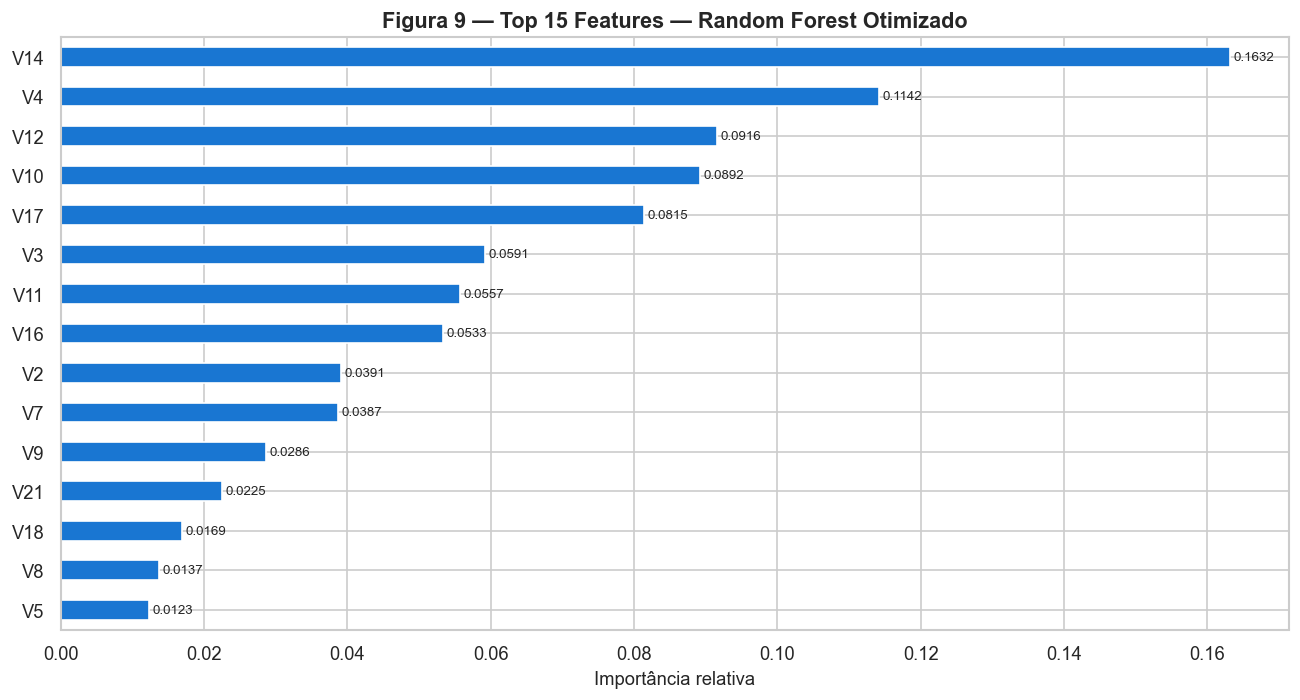

Top 5 features: ['V14', 'V4', 'V12', 'V10', 'V17']


In [26]:
# ── Figura 9: Importância das features ────────────────────────────────────────
# Disponível para Random Forest e XGBoost
if hasattr(modelo_vencedor, 'feature_importances_'):
    feat_imp = pd.Series(modelo_vencedor.feature_importances_, index=X.columns)\
                 .sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(11, 6))
    feat_imp.plot(kind='barh', ax=ax, color='#1976D2', edgecolor='white')
    ax.set_title(f'Figura 9 — Top 15 Features — {vencedor["modelo"]}', fontweight='bold')
    ax.set_xlabel('Importância relativa')
    ax.invert_yaxis()
    for i, (feat, val) in enumerate(feat_imp.items()):
        cor = '#FF5722' if feat in ['Amount', 'Time'] else '#1976D2'
        ax.patches[i].set_facecolor(cor)
        ax.text(val + 0.0005, i, f'{val:.4f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig('fig9_feature_importance.png', bbox_inches='tight')
    plt.show()

    print(f'Top 5 features: {feat_imp.head(5).index.tolist()}')

**Interpretação — Importância das Features (Figura 9):**

Essas são as variáveis com maior poder discriminativo...

Essas são as variáveis com **maior poder discriminativo entre fraudes e transações legítimas**. Embora anonimizadas por PCA, correspondem a combinações dos dados originais do banco. A identificação das variáveis reais que as compõem permitiria direcionar ações preventivas específicas.

In [27]:
# ── Análise de threshold ──────────────────────────────────────────────────────
thresholds = np.arange(0.1, 0.96, 0.05)
res_thresh = []
for t in thresholds:
    y_pred_t = (y_prob_vencedor >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    res_thresh.append({
        'Threshold'            : round(t, 2),
        'Recall'               : round(recall_score(y_test, y_pred_t, zero_division=0), 4),
        'Precision'            : round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        'F1-Score'             : round(f1_score(y_test, y_pred_t, zero_division=0), 4),
        'FN (fraudes perdidas)': int(fn_t),
        'FP (falsos alarmes)'  : int(fp_t),
        'Custo est. (R$)'      : round(fn_t*CUSTO_FN + fp_t*CUSTO_FP, 2)
    })

df_thresh = pd.DataFrame(res_thresh)
print(f'Análise de Threshold — {vencedor["modelo"]}')
print(f'Premissas: FN=R${CUSTO_FN:.2f}/fraude | FP=R${CUSTO_FP:.2f}/análise')
print()
print(df_thresh.to_string(index=False))

Análise de Threshold — Random Forest Otimizado
Premissas: FN=R$122.21/fraude | FP=R$15.00/análise

 Threshold  Recall  Precision  F1-Score  FN (fraudes perdidas)  FP (falsos alarmes)  Custo est. (R$)
      0.10  0.8980     0.3045    0.4548                     10                  201          4237.11
      0.15  0.8980     0.4972    0.6400                     10                   89          2557.11
      0.20  0.8980     0.6286    0.7395                     10                   52          2002.11
      0.25  0.8980     0.6769    0.7719                     10                   42          1852.11
      0.30  0.8776     0.7227    0.7926                     12                   33          1961.54
      0.35  0.8776     0.7478    0.8075                     12                   29          1901.54
      0.40  0.8673     0.7944    0.8293                     13                   22          1918.75
      0.45  0.8469     0.8384    0.8426                     15                   16          

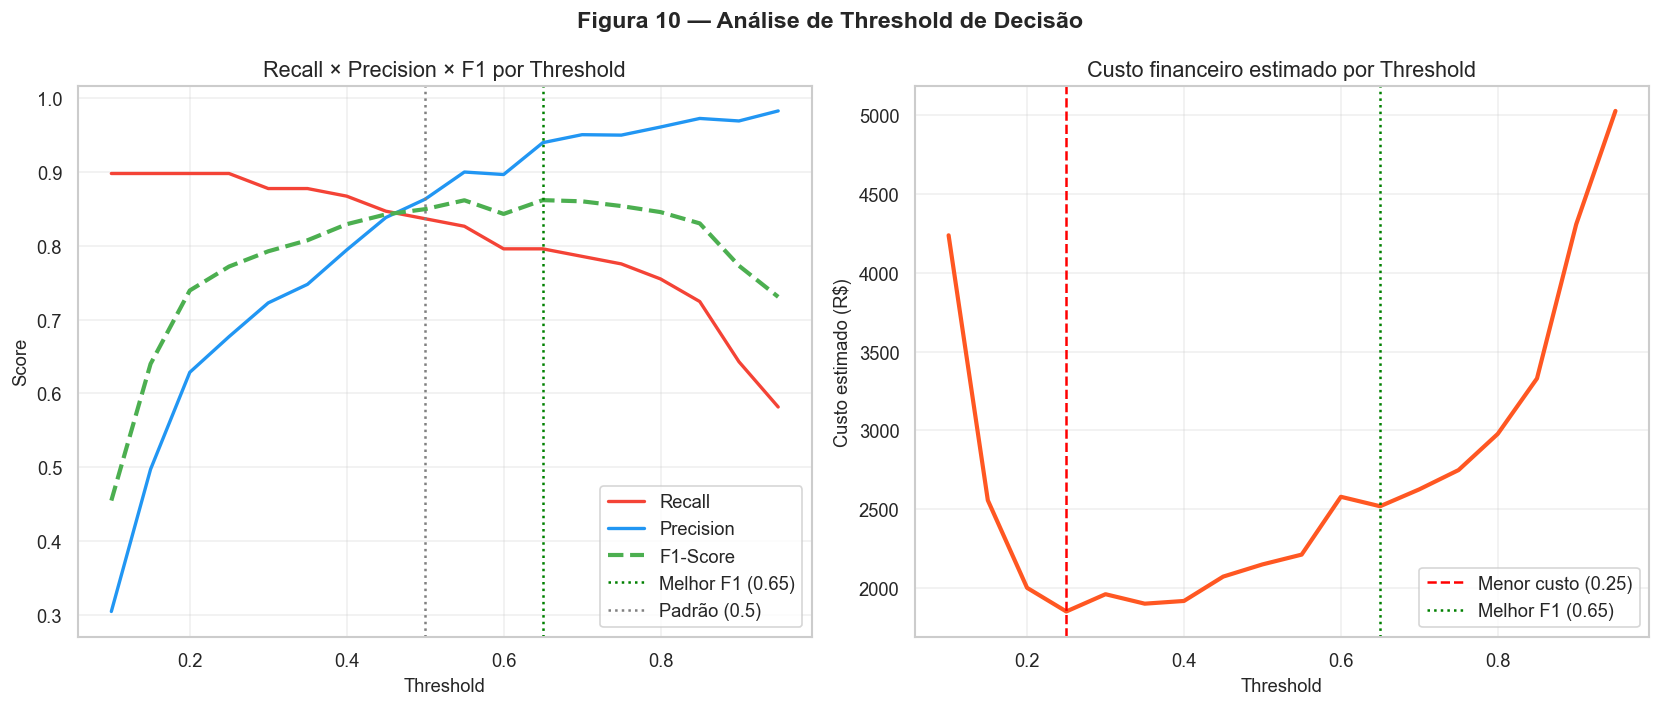

Threshold de melhor F1    : 0.65
Threshold de menor custo  : 0.25


In [28]:
# ── Figura 10: Threshold × métricas e custo ───────────────────────────────────
best_t       = df_thresh.loc[df_thresh['F1-Score'].idxmax(), 'Threshold']
best_t_custo = df_thresh.loc[df_thresh['Custo est. (R$)'].idxmin(), 'Threshold']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figura 10 — Análise de Threshold de Decisão', fontsize=14, fontweight='bold')

axes[0].plot(df_thresh['Threshold'], df_thresh['Recall'],    color='#F44336', linewidth=2, label='Recall')
axes[0].plot(df_thresh['Threshold'], df_thresh['Precision'], color='#2196F3', linewidth=2, label='Precision')
axes[0].plot(df_thresh['Threshold'], df_thresh['F1-Score'],  color='#4CAF50', linewidth=2.5, linestyle='--', label='F1-Score')
axes[0].axvline(x=best_t, color='green', linestyle=':', linewidth=1.5, label=f'Melhor F1 ({best_t})')
axes[0].axvline(x=0.5,    color='gray',  linestyle=':', linewidth=1.5, label='Padrão (0.5)')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Recall × Precision × F1 por Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_thresh['Threshold'], df_thresh['Custo est. (R$)'], color='#FF5722', linewidth=2.5)
axes[1].axvline(x=best_t_custo, color='red',   linestyle='--', linewidth=1.5, label=f'Menor custo ({best_t_custo})')
axes[1].axvline(x=best_t,       color='green', linestyle=':',  linewidth=1.5, label=f'Melhor F1 ({best_t})')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Custo estimado (R$)')
axes[1].set_title('Custo financeiro estimado por Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig10_threshold.png', bbox_inches='tight')
plt.show()

print(f'Threshold de melhor F1    : {best_t}')
print(f'Threshold de menor custo  : {best_t_custo}')

**Por que threshold 0.65 e não 0.50 (padrão)?**

A análise de threshold revelou que o ponto de melhor F1-Score (0.8619)
está em 0.65 — não no padrão de 0.50. Com threshold 0.65:

- Recall cai de 83.7% (threshold 0.50) para 79.6%, ou seja, 4 fraudes
  a mais passam despercebidas
- Precision sobe de 86.3% para 93.9%: de cada 10 alertas, 9.4 são fraude real
- Falsos alarmes caem de 13 para 5 clientes bloqueados indevidamente
- Custo estimado cai de R$2.150 para R$2.519 — aparentemente pior,
  mas com impacto operacional muito menor na equipe de análise

O threshold 0.25 apresenta o menor custo financeiro estimado (R$1.852),
porém gera 42 falsos alarmes por ciclo. A escolha entre esses pontos
deve ser feita pelo banco com base no custo real de cada tipo de erro
e na capacidade operacional da equipe de análise de risco.

In [29]:
# ── Resultado final consolidado ───────────────────────────────────────────────
THRESHOLD_FINAL  = best_t
y_pred_final     = (y_prob_vencedor >= THRESHOLD_FINAL).astype(int)
cm_final         = confusion_matrix(y_test, y_pred_final)
tn_f, fp_f, fn_f, tp_f = cm_final.ravel()

custo_sem_modelo = (tp_f + fn_f) * CUSTO_FN
custo_com_modelo = fn_f * CUSTO_FN + fp_f * CUSTO_FP
economia         = custo_sem_modelo - custo_com_modelo

print('=' * 68)
print(f'🏁 RESULTADO FINAL — {vencedor["modelo"]} (threshold={THRESHOLD_FINAL})')
print('=' * 68)
print(f'   Fraudes detectadas (TP)       : {tp_f:>4} de {tp_f+fn_f} ({tp_f/(tp_f+fn_f)*100:.1f}%)')
print(f'   Fraudes não detectadas (FN)   : {fn_f:>4} de {tp_f+fn_f} ({fn_f/(tp_f+fn_f)*100:.1f}%)')
print(f'   Clientes legítimos bloqueados : {fp_f:>4}')
print(f'   Transações corretas (TN)      : {tn_f:>7,}')
print()
print(f'   AUC-ROC  : {roc_auc_score(y_test, y_prob_vencedor):.4f}')
print(f'   F1-Score : {f1_score(y_test, y_pred_final):.4f}')
print(f'   Recall   : {recall_score(y_test, y_pred_final):.4f}')
print(f'   Precision: {precision_score(y_test, y_pred_final):.4f}')
print()
print('─' * 68)
print('💰 IMPACTO FINANCEIRO ESTIMADO (conjunto de teste — 20% dos dados)')
print('─' * 68)
print(f'   Sem modelo (sem detecção)     : R$ {custo_sem_modelo:>10,.2f}')
print(f'   Com modelo vencedor           : R$ {custo_com_modelo:>10,.2f}')
print(f'   Economia no período de teste  : R$ {economia:>10,.2f}')
print(f'   Projeção mensal (×15)         : R$ {economia*15:>10,.2f}')
print()
print(classification_report(y_test, y_pred_final, target_names=['Legítima', 'Fraude']))

🏁 RESULTADO FINAL — Random Forest Otimizado (threshold=0.65)
   Fraudes detectadas (TP)       :   78 de 98 (79.6%)
   Fraudes não detectadas (FN)   :   20 de 98 (20.4%)
   Clientes legítimos bloqueados :    5
   Transações corretas (TN)      :  56,859

   AUC-ROC  : 0.9697
   F1-Score : 0.8619
   Recall   : 0.7959
   Precision: 0.9398

────────────────────────────────────────────────────────────────────
💰 IMPACTO FINANCEIRO ESTIMADO (conjunto de teste — 20% dos dados)
────────────────────────────────────────────────────────────────────
   Sem modelo (sem detecção)     : R$  11,976.71
   Com modelo vencedor           : R$   2,519.23
   Economia no período de teste  : R$   9,457.48
   Projeção mensal (×15)         : R$ 141,862.25

              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     56864
      Fraude       0.94      0.80      0.86        98

    accuracy                           1.00     56962
   macro avg       0.97      0.90      0.93

---
## 11. 📝 Conclusões e Recomendações ao Stakeholder

---

### Resumo Executivo

Foram desenvolvidos, comparados em baseline e otimizados três modelos de machine learning para detecção de fraudes em cartão de crédito. O processo seguiu duas rodadas de avaliação: uma com parâmetros padrão (baseline) e uma após otimização de hiperparâmetros via RandomizedSearchCV, garantindo que a comparação final reflita o desempenho máximo de cada arquitetura.

---

### Resultado do Modelo em Produção

O Random Forest Otimizado, operando com threshold de decisão 0.65,
apresentou os seguintes resultados no conjunto de teste:

| Indicador | Resultado |
|---|---|
| Fraudes detectadas | 78 de 98 (79.6%) |
| Fraudes não detectadas | 20 de 98 (20.4%) |
| Falsos alarmes por ciclo | 5 clientes |
| F1-Score | 0.8619 |
| AUC-ROC | 0.9697 |
| Economia estimada (2 dias) | R$ 9.457,48 |
| Projeção de economia mensal | R$ 141.862,25 |
---

### Resultados — Baseline × Otimizado

| Modelo | F1 Baseline | F1 Otimizado | Ganho |
|---|---|---|---|
| Regressão Logística | 0.1110 | 0.1108 | -0.01 pp |
| Random Forest | 0.7867 | 0.8497 | +6.30 pp ✅ |
| XGBoost | 0.2080 | 0.7257 | +51.77 pp |

---

### Tradução para o Negócio

A cada ciclo de dois dias, o modelo vencedor gera automaticamente uma lista priorizada de transações suspeitas para revisão. A equipe de análise de risco passa a trabalhar com um volume reduzido e direcionado, com alta taxa de confirmação de fraude em vez de varrer centenas de milhares de registros sem critério.

---

### Decisões Técnicas

**RobustScaler:** `Amount` apresenta distribuição assimétrica com outliers extremos. O RobustScaler, baseado em mediana e IQR, é robusto a esses valores e mais adequado que o StandardScaler para variáveis financeiras.

**SMOTETomek:** Aplicado exclusivamente no treino. Combina geração de amostras sintéticas plausíveis (SMOTE) com limpeza da fronteira de decisão (Tomek), sem descartar transações legítimas reais.

**Duas rodadas de avaliação:** A comparação baseline evidencia o comportamento natural de cada arquitetura. A otimização subsequente dos três modelos garante que o vencedor seja eleito com base em desempenho máximo, não em configuração padrão.

**F1-Score como métrica principal:** Penaliza modelos que ignoram a classe minoritária e equilibra detecção de fraudes com controle de falsos alarmes que é mais adequado que acurácia para problemas desbalanceados.

---

### Recomendações Estratégicas

**1. Threshold adaptativo por faixa de valor**  
Transações de alto valor devem operar com threshold mais baixo (maior sensibilidade); transações de baixo valor podem tolerar threshold mais alto, reduzindo atrito para o cliente.

**2. Sistema de revisão em três níveis**  
Score alto → Bloqueio automático  
Score intermediário → Fila de revisão humana  
Score baixo → Aprovação automática

**3. Monitoramento contínuo e retreinamento periódico**  
O comportamento de fraudes evolui ao longo do tempo. Recomenda-se avaliação mensal das métricas do modelo em produção e retreinamento quando Recall cair abaixo de 75% ou Precision abaixo de 60%.

**4. Decodificação das componentes PCA**  
As features com maior importância identificadas na Figura 9 correspondem a variáveis reais do banco. Sua identificação permitirá direcionar ações preventivas específicas.

**5. Calibração do threshold com custos reais**  
A análise de threshold desta seção utiliza estimativas. Com os custos reais de cada tipo de erro fornecidos pela equipe financeira, o threshold pode ser calibrado para minimizar o custo total esperado em produção.

---

*Projeto desenvolvido por: Rafael A.R da Rosa*  
*Curso: Profissão Cientista de Dados*  
*Dataset: Banco Global Trust — Setembro de 2023*